In [1]:
!pip install seaborn

In [2]:
import os
os.chdir(r"E:\LogAnomalyDetector")
os.getcwd()


'E:\\LogAnomalyDetector'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [4]:
df = pd.read_csv("data/labeled_logs.csv")
df.head()


,timestamp,message,true_label
0,2025-07-23 16:11:43,LEVEL=INFO IP=192.168.1.100,0
1,2025-07-23 16:13:22,LEVEL=WARNING IP=192.168.1.101,0
2,2025-07-23 16:15:11,LEVEL=ERROR IP=nan,1
3,2025-07-23 16:18:53,LEVEL=INFO IP=nan,0
4,2025-07-23 16:21:08,LEVEL=CRITICAL IP=192.168.1.105,1


In [5]:
X_text = df["message"].astype(str)
y_true = df["true_label"].values

len(X_text), len(y_true)


(5, 5)

In [6]:
vectorizer = joblib.load("models/tfidf_vectorizer.joblib")
model = joblib.load("models/best_model.joblib")


In [7]:
X_all = vectorizer.transform(X_text)
X_all.shape


(5, 802)

In [8]:
y_prob = model.predict_proba(X_all)[:, 1]
y_pred = model.predict(X_all)

len(y_prob), len(y_pred)


ValueError: X has 802 features, but RandomForestClassifier is expecting 811 features as input.

In [ ]:
os.makedirs("reports", exist_ok=True)


In [ ]:
precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, linewidth=2)
plt.fill_between(recall, precision, alpha=0.15)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)

plt.savefig("reports/precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred),
    "F1-score": f1_score(y_true, y_pred)
}

plt.figure(figsize=(7, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Metrics")
plt.grid(axis="y")

plt.savefig("reports/model_performance_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

metrics


In [ ]:
import numpy as np

np.percentile(y_prob, [50, 60, 70, 80, 90, 95, 99])


In [ ]:
import os
os.makedirs("reports", exist_ok=True)


In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, linewidth=2)
plt.fill_between(recall, precision, alpha=0.15)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)

plt.savefig("reports/precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred),
    "F1-score": f1_score(y_true, y_pred)
}

plt.figure(figsize=(7, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Metrics")
plt.grid(axis="y")

plt.savefig("reports/model_performance_metrics.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
os.listdir("reports")


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
from scipy.sparse import hstack
from sklearn.metrics import confusion_matrix, f1_score

# Load data
df = pd.read_csv("data/hdfs_processed.csv")

# Load trained artifacts
rf = joblib.load("models/best_model.joblib")
vectorizer = joblib.load("models/tfidf_vectorizer.joblib")

# Load SAME test indices
idx_test = np.load("data/test_indices.npy")

df_test = df.loc[idx_test].copy()

print("✅ Data + model loaded")

✅ Data + model loaded


In [11]:
y_test = df_test["true_label"].values

In [13]:
print(type(y_test), len(y_test))

<class 'numpy.ndarray'> 400


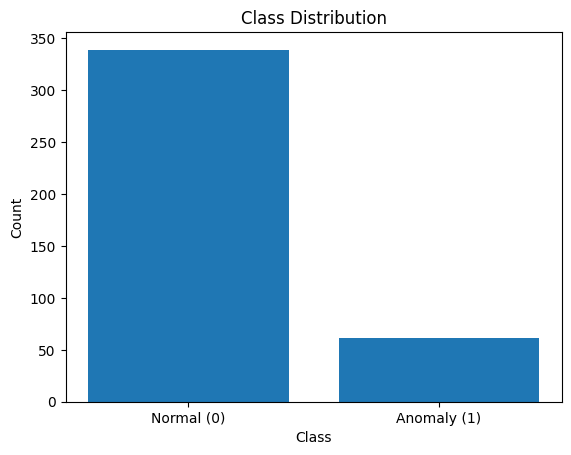


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_class_distribution.png

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import FileLink

# ==============================
# CREATE REPORTS FOLDER
# ==============================
output_dir = "reports"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "fig_class_distribution.png")

# ==============================
# PLOT
# ==============================
counts = np.bincount(y_test)

plt.figure()

plt.bar(["Normal (0)", "Anomaly (1)"], counts)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.savefig(file_path)
plt.show()

# ==============================
# DOWNLOAD LINK
# ==============================
print("\n⬇ Download your graph:")
display(FileLink(file_path))

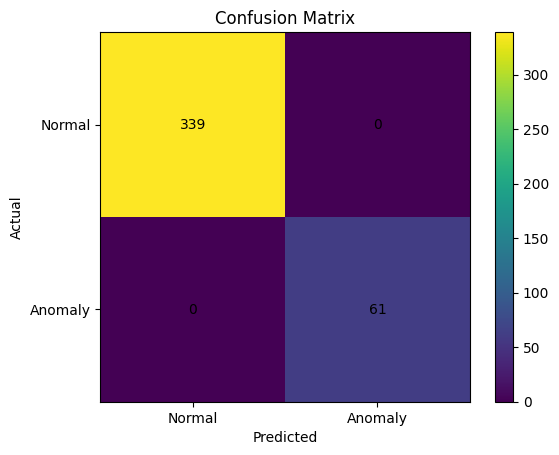


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_confusion_matrix.png

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.metrics import confusion_matrix
import joblib
import os
from IPython.display import FileLink

# ==============================
# LOAD DATA
# ==============================
X = sparse.load_npz("data/X_features.npz").tocsr()
y = np.loadtxt("data/y_labels.csv", delimiter=",", skiprows=1)

rf = joblib.load("models/best_model.joblib")

idx_test = np.load("data/test_indices.npy")

X_test = X[idx_test]
y_test = y[idx_test]

# ==============================
# PREDICTION
# ==============================
y_prob = rf.predict_proba(X_test)[:, 1]
threshold = 0.15
y_pred = (y_prob >= threshold).astype(int)

# ==============================
# CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred)

# ==============================
# SAVE PATH
# ==============================
output_dir = "reports"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "fig_confusion_matrix.png")

# ==============================
# PLOT
# ==============================
plt.figure()

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

labels = ["Normal", "Anomaly"]
plt.xticks(np.arange(2), labels)
plt.yticks(np.arange(2), labels)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(file_path)
plt.show()

# ==============================
# DOWNLOAD
# ==============================
print("\n⬇ Download your graph:")
display(FileLink(file_path))

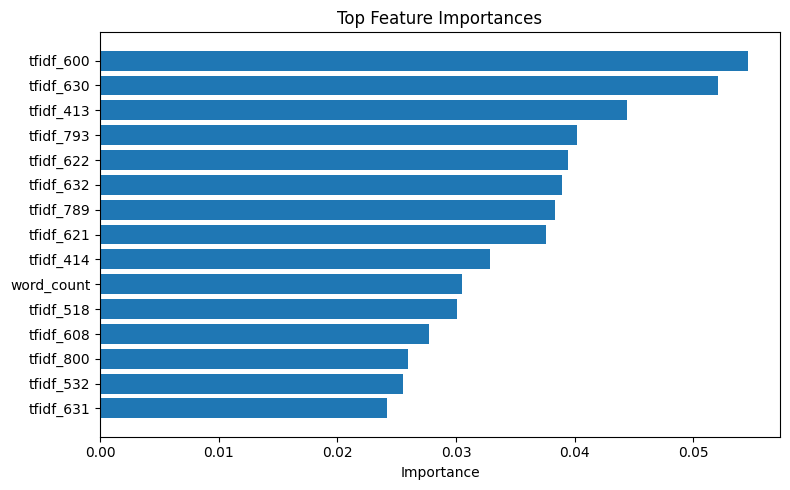


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_feature_importance.png

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from IPython.display import FileLink

# ==============================
# 1. LOAD MODEL
# ==============================
rf = joblib.load("models/best_model.joblib")

# ==============================
# 2. FEATURE IMPORTANCE
# ==============================
importances = rf.feature_importances_

# 🔥 DEFINE FEATURE NAMES (LAST 9 = STRUCTURED)
structured_names = [
    "len_text", "word_count", "has_number",
    "has_block", "long_text",
    "has_packet", "has_namenode",
    "has_replica", "has_storage"
]

n_total = len(importances)

feature_names = []
for i in range(n_total):
    if i < n_total - len(structured_names):
        feature_names.append(f"tfidf_{i}")
    else:
        feature_names.append(structured_names[i - (n_total - len(structured_names))])

# ==============================
# 3. TOP FEATURES (SORTED)
# ==============================
top_n = 15
indices = np.argsort(importances)[::-1][:top_n]  # descending

# ==============================
# 4. CREATE REPORTS FOLDER
# ==============================
output_dir = "reports"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "fig_feature_importance.png")

# ==============================
# 5. PLOT
# ==============================
plt.figure(figsize=(8, 5))

plt.barh(range(top_n), importances[indices][::-1])
plt.yticks(range(top_n), [feature_names[i] for i in indices][::-1])

plt.xlabel("Importance")
plt.title("Top Feature Importances")

plt.tight_layout()

# ==============================
# 6. SAVE FILE
# ==============================
plt.savefig(file_path)
plt.show()

# ==============================
# 7. DOWNLOAD LINK
# ==============================
print("\n⬇ Download your graph:")
display(FileLink(file_path))

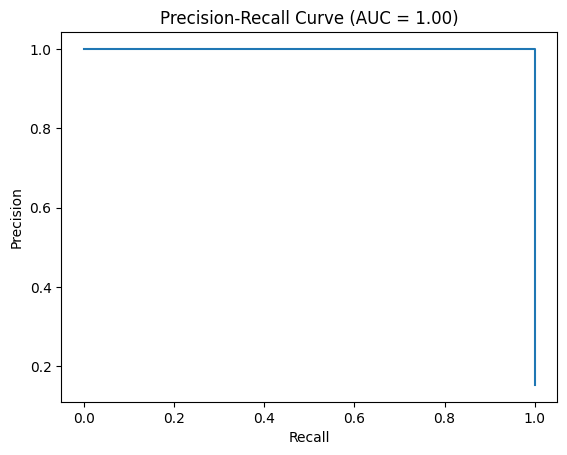


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_precision_recall_curve.png

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from scipy import sparse
import joblib
import os
from IPython.display import FileLink

# Load data
X = sparse.load_npz("data/X_features.npz").tocsr()
y = np.loadtxt("data/y_labels.csv", delimiter=",", skiprows=1)
rf = joblib.load("models/best_model.joblib")
idx_test = np.load("data/test_indices.npy")

X_test = X[idx_test]
y_test = y[idx_test]

# Probabilities
y_prob = rf.predict_proba(X_test)[:, 1]

# PR curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# Save path
os.makedirs("reports", exist_ok=True)
file_path = "reports/fig_precision_recall_curve.png"

# Plot
plt.figure()
plt.plot(recall, precision)
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

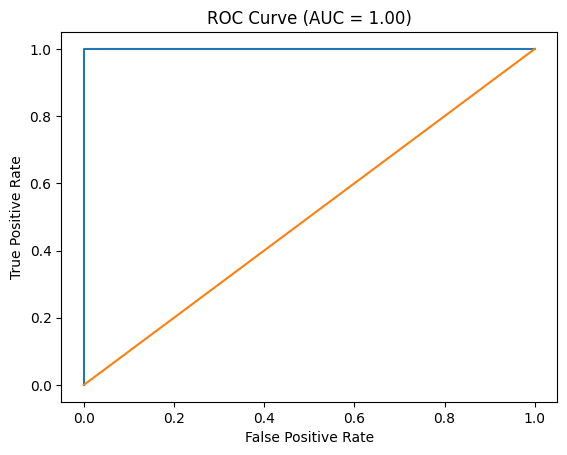


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_roc_curve.png

In [23]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

file_path = "reports/fig_roc_curve.png"

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])  # baseline
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

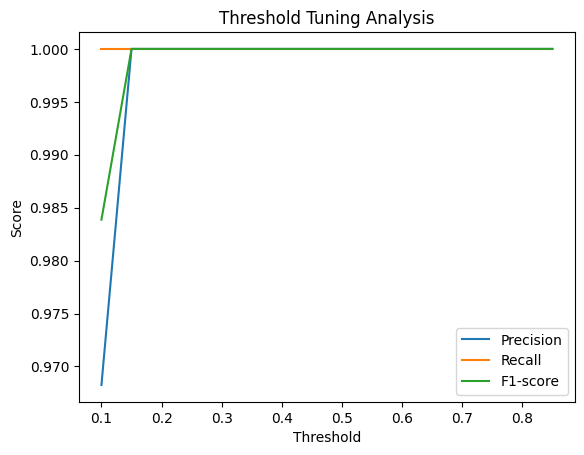


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_threshold_tuning.png

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))

file_path = "reports/fig_threshold_tuning.png"

plt.figure()

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1-score")

plt.title("Threshold Tuning Analysis")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()

plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

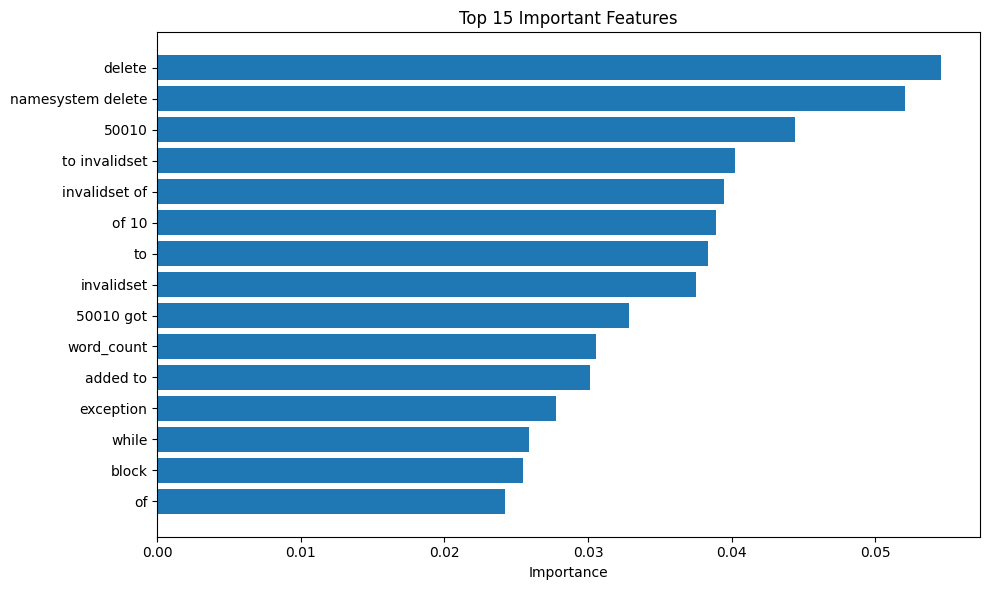


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_feature_importance_clean.png

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from IPython.display import FileLink

# ==============================
# LOAD MODEL + VECTORIZER
# ==============================
rf = joblib.load("models/best_model.joblib")
vectorizer = joblib.load("models/tfidf_vectorizer.joblib")

# ==============================
# FEATURE NAMES
# ==============================
tfidf_features = vectorizer.get_feature_names_out()

structured_features = [
    "text_length",
    "word_count",
    "has_number",
    "has_block",
    "long_text",
    "has_packet",
    "has_namenode",
    "has_replica",
    "has_storage"
]

all_features = list(tfidf_features) + structured_features

# ==============================
# IMPORTANCES
# ==============================
importances = rf.feature_importances_

top_n = 15
indices = np.argsort(importances)[-top_n:]

# Sort for better visualization
sorted_idx = indices[np.argsort(importances[indices])]

# ==============================
# SAVE PATH
# ==============================
os.makedirs("reports", exist_ok=True)
file_path = "reports/fig_feature_importance_clean.png"

# ==============================
# PLOT
# ==============================
plt.figure(figsize=(10, 6))

labels = [all_features[i] for i in sorted_idx]
values = importances[sorted_idx]

plt.barh(range(top_n), values)
plt.yticks(range(top_n), labels)

plt.xlabel("Importance")
plt.title("Top 15 Important Features")

plt.tight_layout()
plt.savefig(file_path)
plt.show()

# ==============================
# DOWNLOAD LINK
# ==============================
print("\n⬇ Download your graph:")
display(FileLink(file_path))

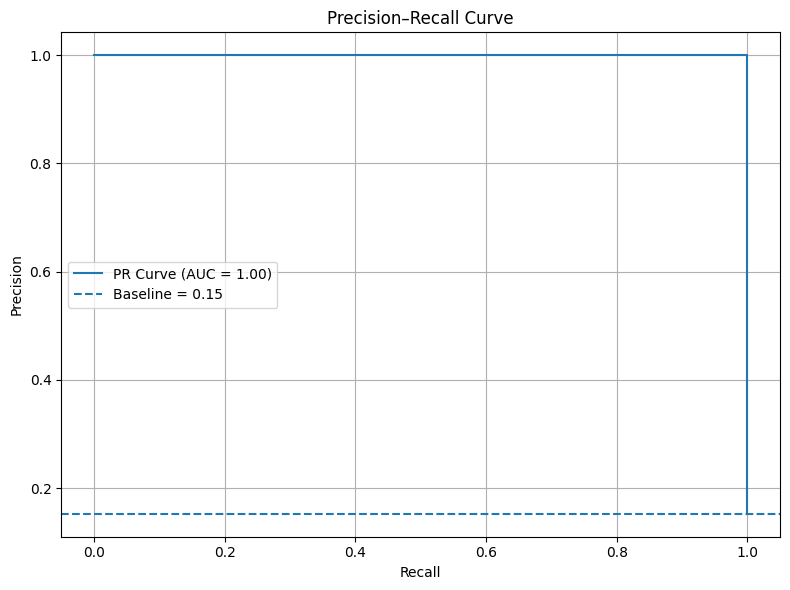


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_precision_recall_curve.png

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from scipy import sparse
import joblib
import os
from IPython.display import FileLink

# ==============================
# LOAD DATA (CORRECT WAY)
# ==============================
X = sparse.load_npz("data/X_features.npz").tocsr()
y = np.loadtxt("data/y_labels.csv", delimiter=",", skiprows=1)

rf = joblib.load("models/best_model.joblib")
idx_test = np.load("data/test_indices.npy")

X_test = X[idx_test]
y_test = y[idx_test]

# ==============================
# PREDICT PROBABILITIES
# ==============================
y_prob = rf.predict_proba(X_test)[:, 1]

# ==============================
# PRECISION-RECALL
# ==============================
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# ==============================
# BASELINE (IMPORTANT)
# ==============================
baseline = np.sum(y_test) / len(y_test)

# ==============================
# SAVE PATH
# ==============================
os.makedirs("reports", exist_ok=True)
file_path = "reports/fig_precision_recall_curve.png"

# ==============================
# PLOT
# ==============================
plt.figure(figsize=(8, 6))

plt.plot(recall, precision, label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.axhline(y=baseline, linestyle="--", label=f"Baseline = {baseline:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")

plt.legend()
plt.grid(True)


plt.tight_layout()
plt.savefig(file_path)
plt.show()

# ==============================
# DOWNLOAD
# ==============================
print("\n⬇ Download your graph:")
display(FileLink(file_path))

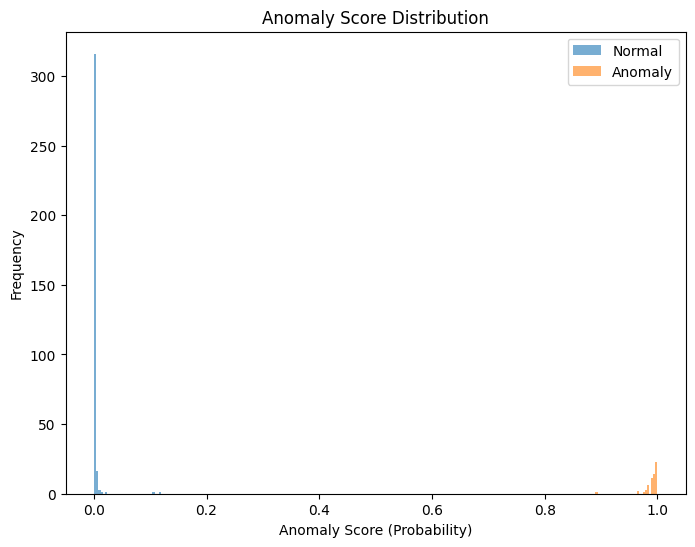


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_score_distribution.png

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import FileLink, display

# ==============================
# SEPARATE PROBABILITIES
# ==============================
normal_probs = y_prob[y_test == 0]
anomaly_probs = y_prob[y_test == 1]

# ==============================
# SAVE PATH
# ==============================
os.makedirs("reports", exist_ok=True)
file_path = "reports/fig_score_distribution.png"

# ==============================
# PLOT
# ==============================
plt.figure(figsize=(8,6))

plt.hist(normal_probs, bins=30, alpha=0.6, label="Normal")
plt.hist(anomaly_probs, bins=30, alpha=0.6, label="Anomaly")

plt.xlabel("Anomaly Score (Probability)")
plt.ylabel("Frequency")
plt.title("Anomaly Score Distribution")
plt.legend()

plt.savefig(file_path)
plt.show()

# ==============================
# DOWNLOAD LINK
# ==============================
print("\n⬇ Download your graph:")
display(FileLink(file_path))

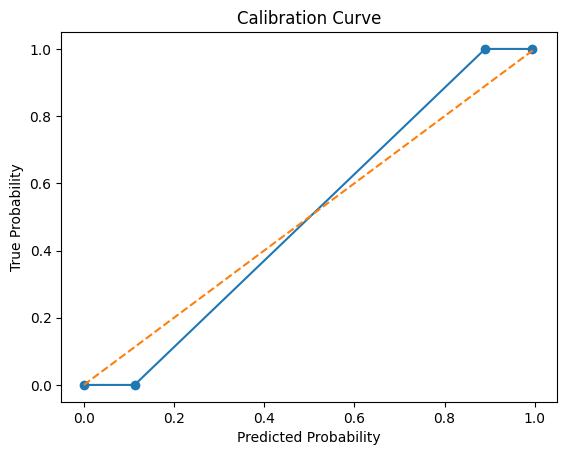


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_calibration_curve.png

In [33]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

file_path = "reports/fig_calibration_curve.png"

plt.figure()

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")

plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

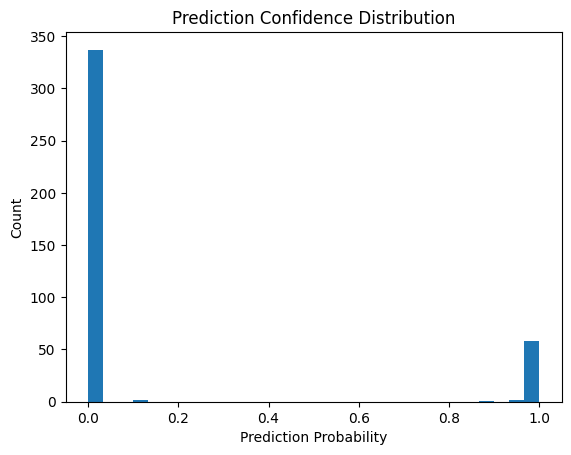


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_confidence_histogram.png

In [34]:
file_path = "reports/fig_confidence_histogram.png"

plt.figure()

plt.hist(y_prob, bins=30)

plt.xlabel("Prediction Probability")
plt.ylabel("Count")
plt.title("Prediction Confidence Distribution")

plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

In [36]:
# ==============================
# LOAD DATA + MODEL
# ==============================
import pandas as pd
import numpy as np
from scipy import sparse
import joblib

from sklearn.model_selection import train_test_split

# Load features
X = sparse.load_npz("data/X_features.npz")
y = pd.read_csv("data/y_labels.csv")["true_label"].values

# SAME split
indices = np.arange(len(y))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==============================
# LOAD MODELS
# ==============================
rf = joblib.load("models/best_model.joblib")

# If you didn't save LR/SVM → retrain quickly
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
svm = LinearSVC(class_weight="balanced")

lr.fit(X_train, y_train)
svm.fit(X_train, y_train)

# ==============================
# PREDICTIONS
# ==============================
y_prob_rf = rf.predict_proba(X_test)[:, 1]
threshold = 0.15

y_pred_rf = (y_prob_rf >= threshold).astype(int)
y_pred_lr = lr.predict(X_test)
y_pred_svm = svm.predict(X_test)

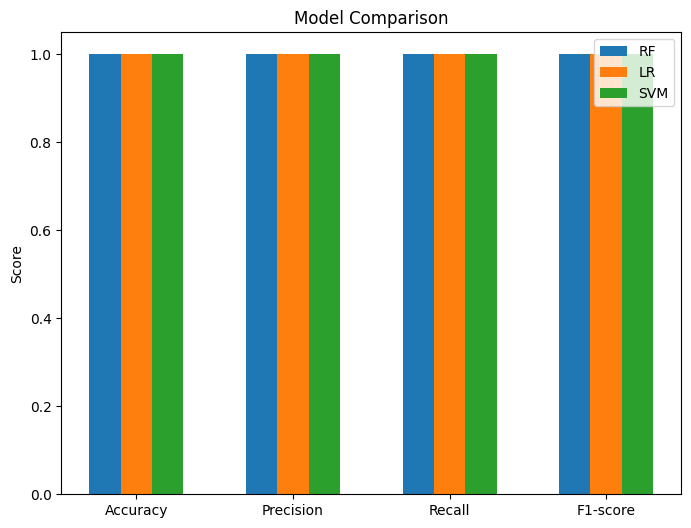

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import os
from IPython.display import FileLink, display

# Metrics
models = ["Random Forest", "Logistic Regression", "SVM"]

rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

lr_scores = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
]

svm_scores = [
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm)
]

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

x = range(len(metrics))

plt.figure(figsize=(8,6))

width = 0.2
x = np.arange(len(metrics))

plt.bar(x - width, rf_scores, width, label="RF")
plt.bar(x, lr_scores, width, label="LR")
plt.bar(x + width, svm_scores, width, label="SVM")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()

plt.savefig("reports/fig_model_comparison_clean.png")
plt.show()

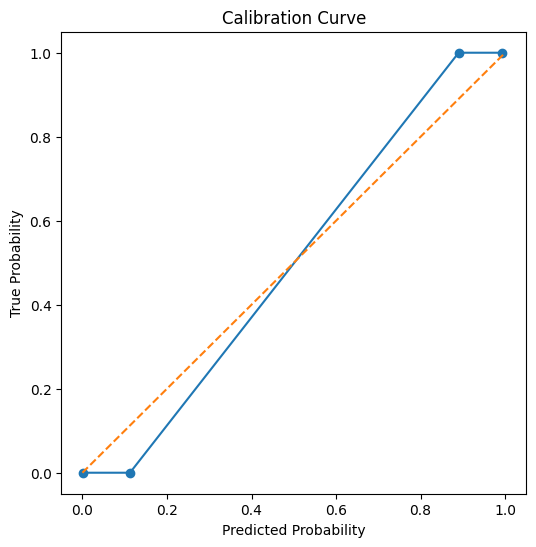


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_calibration_curve.png

In [38]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import os
from IPython.display import FileLink, display

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")

file_path = "reports/fig_calibration_curve.png"
plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

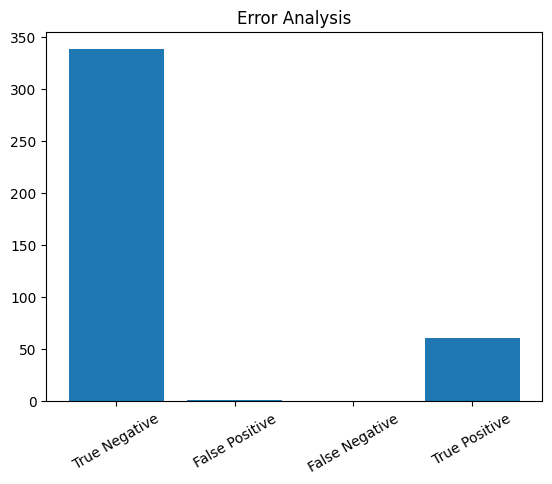


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_error_analysis.png

In [39]:
import matplotlib.pyplot as plt
import os
from IPython.display import FileLink, display

fp = 1
fn = 0
tp = 61
tn = 338

labels = ["True Negative", "False Positive", "False Negative", "True Positive"]
values = [tn, fp, fn, tp]

plt.figure()
plt.bar(labels, values)

plt.title("Error Analysis")
plt.xticks(rotation=30)

file_path = "reports/fig_error_analysis.png"
plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

In [3]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import joblib

# Load trained model
model = joblib.load(r"E:\LogAnomalyDetector\models\best_model.joblib")
vectorizer = joblib.load(r"E:\LogAnomalyDetector\models\tfidf_vectorizer.joblib")

# --- Get predicted probabilities ---
y_prob = model.predict_proba(X_test)[:, 1]

# --- Calibration data ---
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

# --- Plot ---
plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')  # Perfect calibration line

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve (Reliability Diagram)")

plt.savefig("reports/calibration_curve.png")
plt.show()

# --- Brier Score ---
brier = brier_score_loss(y_test, y_prob)
print("Brier Score:", brier)

NameError: name 'X_test' is not defined

In [2]:
from graphviz import Digraph

# Create architecture diagram
arch = Digraph("Adaptive_SOC_Architecture", format="png")

# Global graph settings
arch.attr(rankdir='TB')
arch.attr(splines='ortho')
arch.attr(nodesep='0.5')
arch.attr(ranksep='0.7')
arch.attr(bgcolor='white')

# Default node styling
arch.attr(
    'node',
    shape='box',
    style='rounded,filled',
    fillcolor='#DCEBFA',
    color='#4A6FA5',
    penwidth='1.5',
    fontname='Times New Roman',
    fontsize='12',
    margin='0.2'
)

# ---------------------------
# Architecture Layers
# ---------------------------

arch.node(
    'A',
    'Log Sources Layer\n\n'
    '• System Logs\n'
    '• Network Logs\n'
    '• Application Logs'
)

arch.node(
    'B',
    'Preprocessing Layer\n\n'
    '• Normalization\n'
    '• Duplicate Removal\n'
    '• Timestamp Handling\n'
    '• Text Cleaning'
)

arch.node(
    'C',
    'Feature Extraction Layer\n\n'
    'TF-IDF Vectorization'
)

arch.node(
    'D',
    'Machine Learning Layer\n\n'
    'Random Forest Classifier'
)

arch.node(
    'E',
    'Severity & Threat Analysis Layer\n\n'
    '• LOW\n'
    '• MEDIUM\n'
    '• HIGH'
)

arch.node(
    'F',
    'SOC Monitoring Layer\n\n'
    '• Alert Monitoring\n'
    '• Threat Investigation\n'
    '• Analyst Operations'
)

arch.node(
    'G',
    'Feedback & Retraining Layer\n\n'
    '• Feedback Logs\n'
    '• Lifecycle Management\n'
    '• Optimization Support'
)

# ---------------------------
# Connections
# ---------------------------

arch.edge('A', 'B', arrowsize='0.8')
arch.edge('B', 'C', arrowsize='0.8')
arch.edge('C', 'D', arrowsize='0.8')
arch.edge('D', 'E', arrowsize='0.8')
arch.edge('E', 'F', arrowsize='0.8')
arch.edge('F', 'G', arrowsize='0.8')

# ---------------------------
# Save Diagram
# ---------------------------

output_path = r"E:\SOC_Research_Paper\Figures\adaptive_soc_architecture"

arch.render(output_path, cleanup=True)

print("Architecture diagram generated successfully!")
print(f"Saved at: {output_path}.png")


(process:2108): Pango-WARNING **: 19:14:04.323: couldn't load font "Times New Not-Rotated 12", falling back to "Sans Not-Rotated 12", expect ugly output.


Architecture diagram generated successfully!
Saved at: E:\SOC_Research_Paper\Figures\adaptive_soc_architecture.png


In [3]:
from graphviz import Digraph

# Create architecture diagram
arch = Digraph("Adaptive_SOC_Architecture", format="png")

# Global graph settings
arch.attr(rankdir='TB')
arch.attr(splines='ortho')
arch.attr(nodesep='0.5')
arch.attr(ranksep='0.7')
arch.attr(bgcolor='white')

# Default node styling
arch.attr(
    'node',
    shape='box',
    style='rounded,filled',
    fillcolor='#DCEBFA',
    color='#4A6FA5',
    penwidth='1.5',
    fontname='Times New Roman',
    fontsize='12',
    margin='0.2'
)

# ---------------------------
# Architecture Layers
# ---------------------------

arch.node(
    'A',
    'Log Sources Layer\n\n'
    '• System Logs\n'
    '• Network Logs\n'
    '• Application Logs'
)

arch.node(
    'B',
    'Preprocessing Layer\n\n'
    '• Normalization\n'
    '• Duplicate Removal\n'
    '• Timestamp Handling\n'
    '• Text Cleaning'
)

arch.node(
    'C',
    'Feature Extraction Layer\n\n'
    'TF-IDF Vectorization'
)

arch.node(
    'D',
    'Machine Learning Layer\n\n'
    'Random Forest Classifier'
)

arch.node(
    'E',
    'Severity & Threat Analysis Layer\n\n'
    '• LOW\n'
    '• MEDIUM\n'
    '• HIGH'
)

arch.node(
    'F',
    'SOC Monitoring Layer\n\n'
    '• Alert Monitoring\n'
    '• Threat Investigation\n'
    '• Analyst Operations'
)

arch.node(
    'G',
    'Feedback & Retraining Layer\n\n'
    '• Feedback Logs\n'
    '• Lifecycle Management\n'
    '• Optimization Support'
)

# ---------------------------
# Connections
# ---------------------------

arch.edge('A', 'B', arrowsize='0.8')
arch.edge('B', 'C', arrowsize='0.8')
arch.edge('C', 'D', arrowsize='0.8')
arch.edge('D', 'E', arrowsize='0.8')
arch.edge('E', 'F', arrowsize='0.8')
arch.edge('F', 'G', arrowsize='0.8')

# ---------------------------
# Save Diagram
# ---------------------------

output_path = r"E:\SOC_Research_Paper\Figures\adaptive_soc_architecture"

arch.render(output_path, cleanup=True)

print("Architecture diagram generated successfully!")
print(f"Saved at: {output_path}.png")


(process:10848): Pango-WARNING **: 21:28:50.249: couldn't load font "Times New Not-Rotated 12", falling back to "Sans Not-Rotated 12", expect ugly output.


Architecture diagram generated successfully!
Saved at: E:\SOC_Research_Paper\Figures\adaptive_soc_architecture.png


In [5]:
from graphviz import Digraph

arch = Digraph("Adaptive_SOC_Architecture", format="png")

# =========================
# GLOBAL SETTINGS
# =========================
arch.attr(rankdir='TB')
arch.attr(splines='ortho')
arch.attr(nodesep='0.8')
arch.attr(ranksep='1')
arch.attr(bgcolor='white')
arch.attr(pad='0.3')

# Node style
arch.attr(
    'node',
    shape='box',
    style='rounded,filled',
    fillcolor='#EAF2FF',
    color='#4A6FA5',
    penwidth='1.5',
    fontname='Arial',
    fontsize='14',
    margin='0.25'
)

# =========================
# MAIN LAYERS
# =========================

arch.node(
    'A',
    'Log Collection Layer\n\n'
    '• System Logs\n'
    '• Network Logs\n'
    '• Application Logs',
    width='3'
)

arch.node(
    'B',
    'Preprocessing Layer\n\n'
    '• Normalization\n'
    '• Duplicate Removal\n'
    '• Timestamp Handling\n'
    '• Text Cleaning',
    width='3.2'
)

arch.node(
    'C',
    'Feature Engineering Layer\n\n'
    'TF-IDF Vectorization',
    width='3'
)

arch.node(
    'D',
    'Machine Learning Layer\n\n'
    'Random Forest Classifier',
    width='3'
)

arch.node(
    'E',
    'Severity & Threat Analysis\n\n'
    'LOW  |  MEDIUM  |  HIGH',
    width='3.3'
)

arch.node(
    'F',
    'SOC Monitoring Layer\n\n'
    '• Alert Monitoring\n'
    '• Threat Investigation\n'
    '• Analyst Operations\n'
    '• Case Management',
    width='3.4'
)

arch.node(
    'G',
    'Feedback & Retraining Layer\n\n'
    '• Feedback Logs\n'
    '• Lifecycle Management\n'
    '• Model Optimization',
    width='3.4'
)

# =========================
# MAIN FLOW
# =========================

arch.edge('A', 'B', arrowsize='0.8')
arch.edge('B', 'C', arrowsize='0.8')
arch.edge('C', 'D', arrowsize='0.8')
arch.edge('D', 'E', arrowsize='0.8')
arch.edge('E', 'F', arrowsize='0.8')
arch.edge('F', 'G', arrowsize='0.8')

# Feedback loop
arch.edge(
    'G',
    'D',
    style='dashed',
    color='red',
    label='Retraining Feedback',
    fontsize='11'
)

# =========================
# SAVE
# =========================

output_path = r"E:\SOC_Research_Paper\Figures\vertical_soc_architecture"

arch.render(output_path, cleanup=True)

print("Vertical professional architecture generated successfully!")
print(f"Saved at: {output_path}.png")

Vertical professional architecture generated successfully!
Saved at: E:\SOC_Research_Paper\Figures\vertical_soc_architecture.png


In [6]:
from graphviz import Digraph

# Create Diagram
arch = Digraph("Adaptive_SOC_Architecture_Final", format="png")

# =========================
# GLOBAL SETTINGS
# =========================
arch.attr(
    rankdir='TB',
    splines='ortho',
    nodesep='0.8',
    ranksep='0.9',
    pad='0.4',
    bgcolor='white'
)

# Default node style
arch.attr(
    'node',
    shape='box',
    style='rounded,filled',
    fillcolor='#EAF2FF',
    color='#4A6FA5',
    penwidth='1.5',
    fontname='Arial',
    fontsize='13',
    margin='0.25'
)

# =========================
# MAIN PIPELINE
# =========================

arch.node(
    'A',
    'Log Sources Layer\n\n'
    '• System Logs\n'
    '• Network Logs\n'
    '• Application Logs',
    width='3.2'
)

arch.node(
    'B',
    'Preprocessing Layer\n\n'
    '• Normalization\n'
    '• Duplicate Removal\n'
    '• Timestamp Handling\n'
    '• Text Cleaning',
    width='3.4'
)

arch.node(
    'C',
    'Feature Engineering Layer\n\n'
    'TF-IDF Vectorization',
    width='3.1'
)

arch.node(
    'D',
    'Machine Learning Layer\n\n'
    'Random Forest Classifier',
    width='3.1'
)

arch.node(
    'E',
    'Severity & Threat Analysis\n\n'
    'LOW  |  MEDIUM  |  HIGH',
    width='3.5'
)

# =========================
# SOC SIDE MODULES
# =========================

arch.node(
    'F1',
    'SOC Monitoring\n\n'
    '• Alert Monitoring\n'
    '• Threat Investigation',
    width='3'
)

arch.node(
    'F2',
    'Analyst Operations\n\n'
    '• Analyst Actions\n'
    '• Case Management',
    width='3'
)

# =========================
# FEEDBACK LAYER
# =========================

arch.node(
    'G',
    'Feedback & Retraining Layer\n\n'
    '• Feedback Logs\n'
    '• Lifecycle Management\n'
    '• Model Optimization',
    width='3.5'
)

# =========================
# MAIN FLOW
# =========================

arch.edge('A', 'B', arrowsize='0.8')
arch.edge('B', 'C', arrowsize='0.8')
arch.edge('C', 'D', arrowsize='0.8')
arch.edge('D', 'E', arrowsize='0.8')

# =========================
# PARALLEL SOC BRANCH
# =========================

arch.edge('E', 'F1', arrowsize='0.8')
arch.edge('E', 'F2', arrowsize='0.8')

# Align F1 and F2 horizontally
with arch.subgraph() as s:
    s.attr(rank='same')
    s.node('F1')
    s.node('F2')

# =========================
# MERGE TO FEEDBACK
# =========================

arch.edge('F1', 'G', arrowsize='0.8')
arch.edge('F2', 'G', arrowsize='0.8')

# =========================
# RETRAINING LOOP
# =========================

arch.edge(
    'G',
    'D',
    style='dashed',
    color='red',
    label='Adaptive Retraining',
    fontsize='11',
    arrowsize='0.8'
)

# =========================
# SAVE OUTPUT
# =========================

output_path = r"E:\SOC_Research_Paper\Figures\final_refined_soc_architecture"

arch.render(output_path, cleanup=True)

print("Final refined architecture diagram generated successfully!")
print(f"Saved at: {output_path}.png")

Final refined architecture diagram generated successfully!
Saved at: E:\SOC_Research_Paper\Figures\final_refined_soc_architecture.png


In [1]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax)

# Title
plt.title("Confusion Matrix - Random Forest")

# Save figure
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')

# Show figure
plt.show()

NameError: name 'y_test' is not defined

In [4]:
import os

print(os.listdir(r"E:\LogAnomalyDetector"))

['.git', '.gitignore', '.ipynb_checkpoints', '.venv', 'app', 'backups', 'backup_full', 'backup_full.zip', 'class_distribution.png', 'confusion_matrix_final.png', 'data', 'feature_importance.png', 'HDFS.npz', 'HDFS.npz.zip', 'live_system.log', 'logs', 'models', 'notebooks', 'python inject_test.py', 'readme.md', 'reports', 'requirements.txt', 'retrain_with_feedback.py', 'scripts', 'src', 'start_all.bat', 'structure.txt', 'system architecture.png']


In [5]:
print(os.listdir(r"E:\LogAnomalyDetector\data"))

['adfa_parsed.csv', 'adfa_raw', 'datasets', 'external_datasets', 'feedback_dataset.csv', 'feedback_dataset.xlsx', 'HDFS.zip', 'hdfs_processed.csv', 'hdfs_small', 'labeled_live_logs.csv', 'labeled_logs.csv', 'labeled_logs_large.csv', 'parsed_live_logs.csv', 'parsed_logs.csv', 'predicted_live_logs.csv', 'preprocessed_hdfs.csv', 'preprocessed_logs.csv', 'test_indices.npy', 'X_features.npz', 'y_labels.csv']


In [6]:
print(os.listdir(r"E:\LogAnomalyDetector\logs"))

['.sample_simulator.offset', 'anomalies_log.bak.csv', 'anomalies_log.bak2.csv', 'anomalies_log.csv', 'anomalies_log.csv.orig', 'anomalies_log_old.csv', 'anomaly_actions.json', 'archives', 'live_system.log', 'sample.log', 'tmp015n8p1g', 'tmp0czd_5jr', 'tmp0hyx0ljj', 'tmp0izxr09r', 'tmp0kyol13y', 'tmp0l92hhi2', 'tmp0p0zg182', 'tmp0_11utfa', 'tmp1v5u7x4a', 'tmp27e37q15', 'tmp2b88h8rp', 'tmp2wlncael', 'tmp32s5bq4x', 'tmp3ey1kqg5', 'tmp3nmlq9gq', 'tmp402_qyjo', 'tmp46mczsuz', 'tmp4wvaaw3g', 'tmp4wv_p9_h', 'tmp4z7_fmfj', 'tmp5j2ldhd5', 'tmp5j582mc7', 'tmp5kpiof3j', 'tmp5r8oz6lv', 'tmp5rhv7dt9', 'tmp67j0fgym', 'tmp6bkq3xr7', 'tmp6c7be6ta', 'tmp6jzcst4b', 'tmp6twc620x', 'tmp6zzfj26x', 'tmp71s34rq0', 'tmp7uajo164', 'tmp85m_cj30', 'tmp85rc5e3_', 'tmp8nfssjrd', 'tmp8oco9a06', 'tmp8t4sr1ih', 'tmp8usqqfao', 'tmp8v9p1opj', 'tmp96s2w1du', 'tmp9ja69v_k', 'tmp9oo9o2o6', 'tmp9twl9vau', 'tmp9v1788dc', 'tmp9xmsj48v', 'tmpa4rw013_', 'tmpajihaj1h', 'tmpax8aiyqp', 'tmpb27o1fts', 'tmpb755s5q1', 'tmpbaaw64wd',

In [8]:
print(df.columns)

Index(['timestamp', 'message', 'true_label'], dtype='object')


In [10]:
print(df.shape)

(5, 3)


In [11]:
df = pd.read_csv(
    r"E:\LogAnomalyDetector\data\labeled_logs_large.csv"
)

print(df.shape)
print(df.columns)

(5990, 2)
Index(['message', 'true_label'], dtype='object')


Dataset Shape:

(5990, 2)

Dataset Columns:

Index(['message', 'true_label'], dtype='object')

Random Forest Parameters:

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Confusion Matrix saved at:
E:\SOC_Research_Paper\Figures\confusion_matrix.png


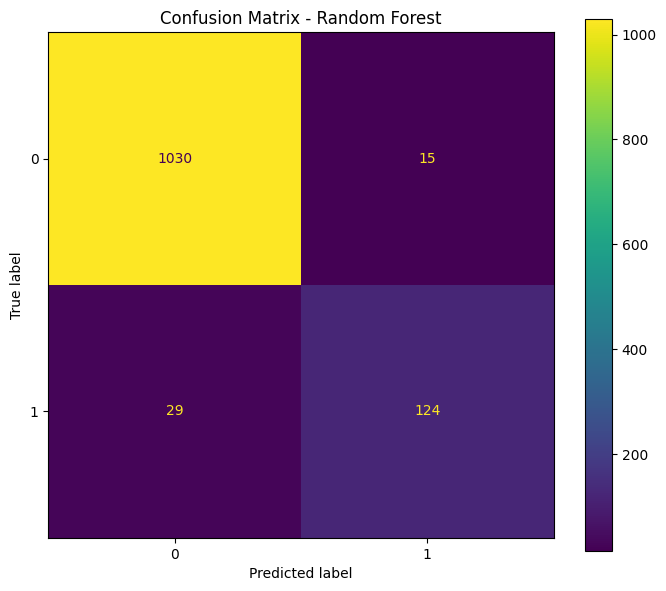

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv(
    r"E:\LogAnomalyDetector\data\labeled_logs_large.csv"
)

# =========================
# DATASET INFORMATION
# =========================

print("Dataset Shape:\n")
print(df.shape)

print("\nDataset Columns:\n")
print(df.columns)

# =========================
# FEATURES AND LABELS
# =========================

X = df['message']
y = df['true_label']

# =========================
# TF-IDF FEATURE EXTRACTION
# =========================

vectorizer = TfidfVectorizer(
    max_features=5000
)

X_vectorized = vectorizer.fit_transform(X)

# =========================
# TRAIN-TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# RANDOM FOREST MODEL
# =========================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# =========================
# TRAIN MODEL
# =========================

rf_model.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================

y_pred = rf_model.predict(X_test)

# Probability Predictions
y_proba = rf_model.predict_proba(X_test)[:, 1]

# =========================
# PRINT MODEL PARAMETERS
# =========================

print("\nRandom Forest Parameters:\n")
print(rf_model.get_params())

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

# Create Figure
fig, ax = plt.subplots(figsize=(7,6))

# Plot Matrix
disp.plot(ax=ax)

# Title
plt.title("Confusion Matrix - Random Forest")

# Better Layout
plt.tight_layout()

# =========================
# SAVE FIGURE
# =========================

save_path = r"E:\SOC_Research_Paper\Figures\confusion_matrix.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

print(f"\nConfusion Matrix saved at:\n{save_path}")

# =========================
# SHOW FIGURE
# =========================

plt.show()


ROC Curve saved at:
E:\SOC_Research_Paper\Figures\roc_curve.png


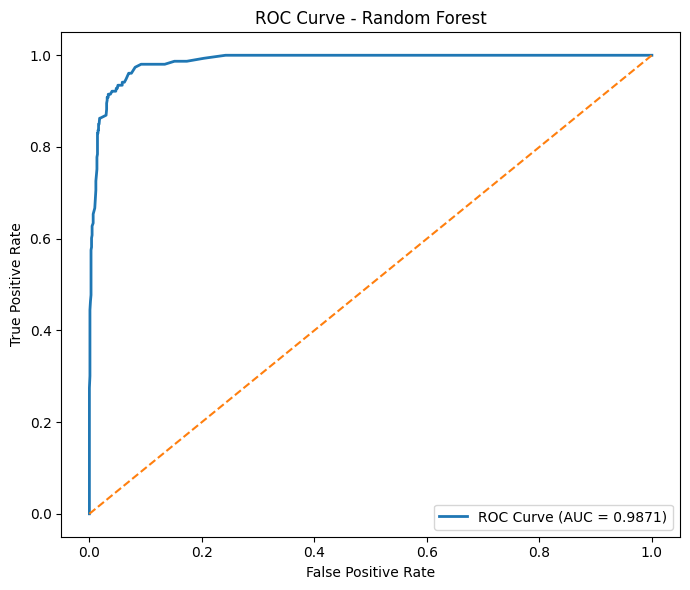


AUC Score: 0.9871


In [15]:
from sklearn.metrics import roc_curve, auc

# =========================
# ROC CURVE
# =========================

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc = auc(fpr, tpr)

# Create Figure
plt.figure(figsize=(7,6))

# Plot ROC Curve
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)

# Diagonal Reference Line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

# Labels and Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend(loc="lower right")

plt.tight_layout()

# =========================
# SAVE FIGURE
# =========================

save_path = r"E:\SOC_Research_Paper\Figures\roc_curve.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

print(f"\nROC Curve saved at:\n{save_path}")

# Show Plot
plt.show()

# Print AUC Score
print(f"\nAUC Score: {roc_auc:.4f}")


Threshold Tuning Graph saved at:
E:\SOC_Research_Paper\Figures\threshold_tuning.png


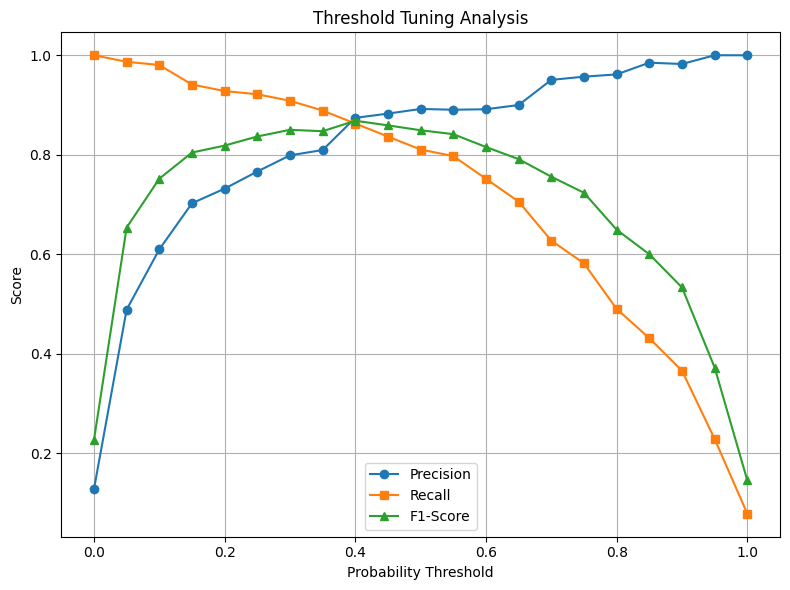

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# =========================
# THRESHOLD VALUES
# =========================

thresholds = np.arange(0.0, 1.01, 0.05)

precision_list = []
recall_list = []
f1_list = []

# =========================
# CALCULATE METRICS
# =========================

for threshold in thresholds:

    y_pred_threshold = (
        y_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold
    )

    recall = recall_score(
        y_test,
        y_pred_threshold
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

# =========================
# PLOT GRAPH
# =========================

plt.figure(figsize=(8,6))

plt.plot(
    thresholds,
    precision_list,
    marker='o',
    label='Precision'
)

plt.plot(
    thresholds,
    recall_list,
    marker='s',
    label='Recall'
)

plt.plot(
    thresholds,
    f1_list,
    marker='^',
    label='F1-Score'
)

# Labels
plt.xlabel("Probability Threshold")
plt.ylabel("Score")

# Title
plt.title(
    "Threshold Tuning Analysis"
)

# Grid
plt.grid(True)

# Legend
plt.legend()

# Better Layout
plt.tight_layout()

# =========================
# SAVE FIGURE
# =========================

save_path = (
    r"E:\SOC_Research_Paper\Figures\threshold_tuning.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

print(
    f"\nThreshold Tuning Graph saved at:\n{save_path}"
)

# Show Figure
plt.show()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from scipy import sparse

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)

# ==============================
# GRAPH SAVE DIRECTORY
# ==============================

GRAPH_DIR = (
    "E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation"
)

os.makedirs(
    GRAPH_DIR,
    exist_ok=True
)

print(
    "✅ Visualization Environment Ready"
)

print(
    f"\nGraphs will be saved to:\n{GRAPH_DIR}"
)

✅ Visualization Environment Ready

Graphs will be saved to:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation


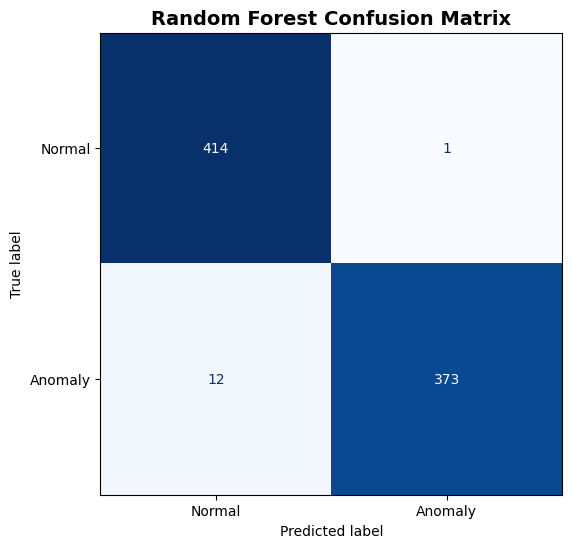


✅ RF Confusion Matrix Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/confusion_matrix_rf.png


In [2]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==============================
# LOAD TEST RESULTS
# ==============================

rf_model = joblib.load(
    "E:/LogAnomalyDetector/models/random_forest_model.joblib"
)

X = sparse.load_npz(
    "E:/LogAnomalyDetector/data/processed/X_features.npz"
)

metadata = pd.read_csv(
    "E:/LogAnomalyDetector/data/processed/y_labels.csv"
)

y = metadata["true_label"].values

# ==============================
# LOAD TEST INDICES
# ==============================

test_indices = np.load(
    "E:/LogAnomalyDetector/data/processed/test_indices.npy"
)

X_test = X[test_indices]

y_test = y[test_indices]

# ==============================
# PREDICT
# ==============================

y_pred_rf = rf_model.predict(X_test)

# ==============================
# CONFUSION MATRIX
# ==============================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "Normal",
        "Anomaly"
    ]
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

save_path = (
    f"{GRAPH_DIR}/confusion_matrix_rf.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ RF Confusion Matrix Saved:\n{save_path}"
)

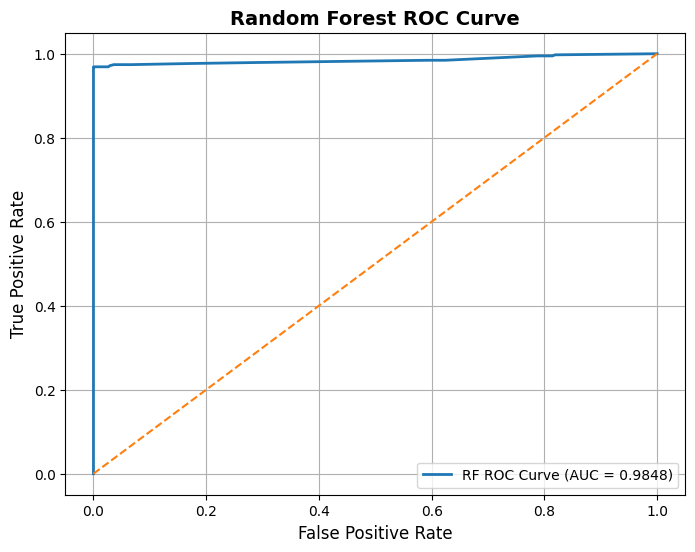


✅ ROC Curve Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/roc_curve_rf.png

ROC-AUC Score: 0.9848


In [3]:
from sklearn.metrics import roc_curve, auc

# ==============================
# LOAD PROBABILITIES
# ==============================

y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

# ==============================
# ROC CURVE
# ==============================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_rf
)

roc_auc = auc(
    fpr,
    tpr
)

# ==============================
# PLOT ROC
# ==============================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"RF ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "Random Forest ROC Curve",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    loc="lower right"
)

plt.grid(True)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/roc_curve_rf.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ ROC Curve Saved:\n{save_path}"
)

print(
    f"\nROC-AUC Score: {roc_auc:.4f}"
)

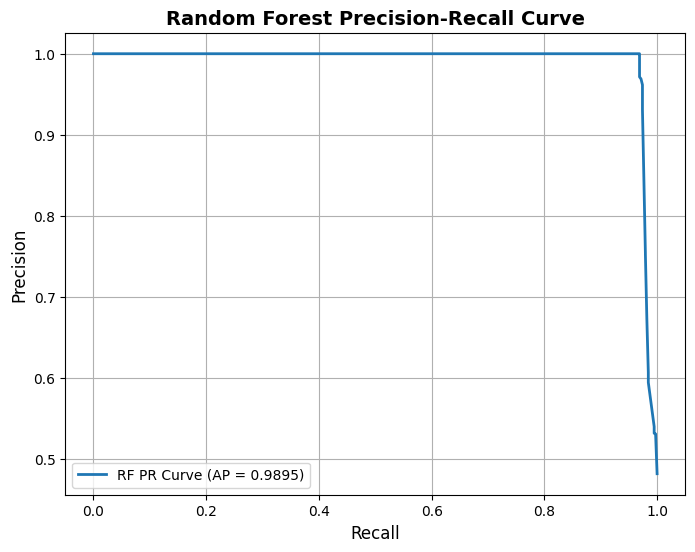


✅ Precision-Recall Curve Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/precision_recall_curve_rf.png

Average Precision Score: 0.9895


In [4]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

# ==============================
# PRECISION-RECALL CURVE
# ==============================

precision, recall, thresholds = (
    precision_recall_curve(
        y_test,
        y_prob_rf
    )
)

avg_precision = average_precision_score(
    y_test,
    y_prob_rf
)

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"RF PR Curve (AP = {avg_precision:.4f})"
)

plt.xlabel(
    "Recall",
    fontsize=12
)

plt.ylabel(
    "Precision",
    fontsize=12
)

plt.title(
    "Random Forest Precision-Recall Curve",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    loc="lower left"
)

plt.grid(True)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/precision_recall_curve_rf.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Precision-Recall Curve Saved:\n{save_path}"
)

print(
    f"\nAverage Precision Score: {avg_precision:.4f}"
)

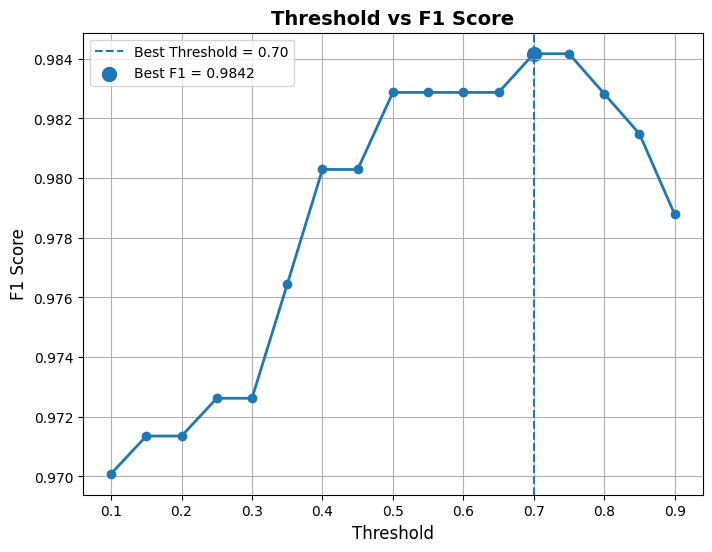


✅ Threshold Analysis Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/threshold_vs_f1_rf.png

Best Threshold: 0.70
Best F1 Score: 0.9842


In [5]:
from sklearn.metrics import (
    f1_score
)

# ==============================
# THRESHOLD ANALYSIS
# ==============================

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

f1_scores = []

for t in thresholds:

    preds = (
        y_prob_rf >= t
    ).astype(int)

    score = f1_score(
        y_test,
        preds
    )

    f1_scores.append(score)

# ==============================
# BEST THRESHOLD
# ==============================

best_idx = np.argmax(
    f1_scores
)

best_threshold = thresholds[best_idx]

best_f1 = f1_scores[best_idx]

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(8, 6))

plt.plot(
    thresholds,
    f1_scores,
    marker="o",
    linewidth=2
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.scatter(
    best_threshold,
    best_f1,
    s=100,
    label=f"Best F1 = {best_f1:.4f}"
)

plt.xlabel(
    "Threshold",
    fontsize=12
)

plt.ylabel(
    "F1 Score",
    fontsize=12
)

plt.title(
    "Threshold vs F1 Score",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(True)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/threshold_vs_f1_rf.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Threshold Analysis Saved:\n{save_path}"
)

print(
    f"\nBest Threshold: {best_threshold:.2f}"
)

print(
    f"Best F1 Score: {best_f1:.4f}"
)


Top Important Features:
                 feature  importance
102            tfidf_102    0.090098
107            tfidf_107    0.069064
1310          tfidf_1310    0.055187
723            tfidf_723    0.048317
1313          tfidf_1313    0.042973
104            tfidf_104    0.040570
1314          tfidf_1314    0.037014
766            tfidf_766    0.034711
1329  contains_exception    0.020857
1311          tfidf_1311    0.020779
188            tfidf_188    0.018131
191            tfidf_191    0.017595
450            tfidf_450    0.015908
105            tfidf_105    0.012744
691            tfidf_691    0.012660


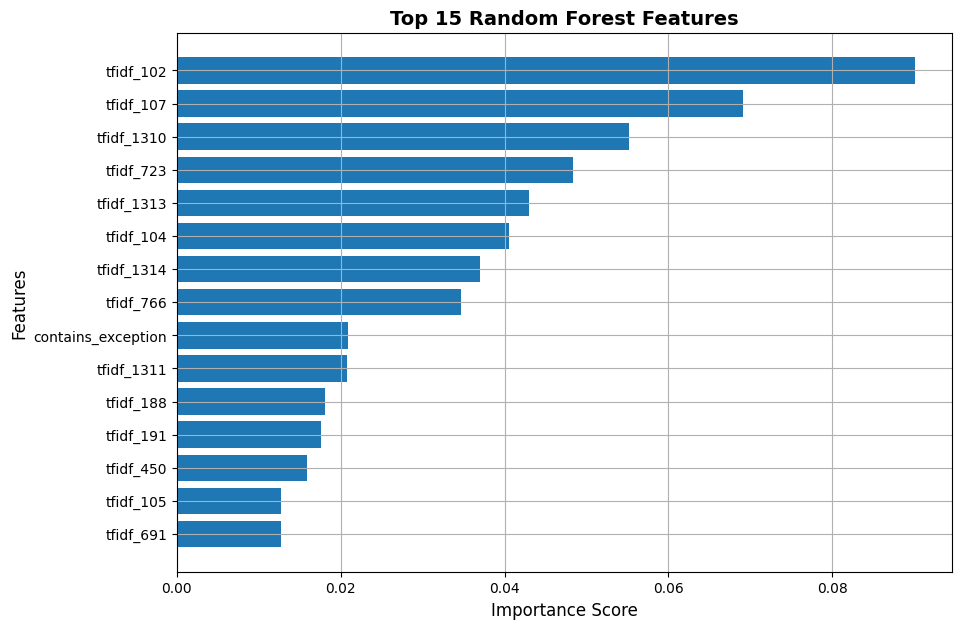


✅ Feature Importance Graph Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/feature_importance_rf.png


In [6]:
# ==============================
# FEATURE IMPORTANCE
# ==============================

importances = rf_model.feature_importances_

# ==============================
# GENERATE FEATURE NAMES
# ==============================

tfidf_feature_count = (
    X.shape[1] - 14
)

tfidf_feature_names = [
    f"tfidf_{i}"
    for i in range(tfidf_feature_count)
]

structured_feature_names = [
    "message_length",
    "token_count",
    "digit_ratio",
    "uppercase_ratio",
    "special_char_count",
    "numeric_token_count",
    "unique_token_ratio",
    "contains_ip",
    "contains_url",
    "contains_path",
    "contains_port",
    "contains_hex",
    "contains_failure",
    "contains_exception"
]

all_feature_names = (
    tfidf_feature_names
    + structured_feature_names
)

# ==============================
# TOP FEATURES
# ==============================

feature_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
})

feature_df = (
    feature_df
    .sort_values(
        by="importance",
        ascending=False
    )
)

top_features = feature_df.head(15)

print("\nTop Important Features:")
print(top_features)

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel(
    "Importance Score",
    fontsize=12
)

plt.ylabel(
    "Features",
    fontsize=12
)

plt.title(
    "Top 15 Random Forest Features",
    fontsize=14,
    fontweight="bold"
)

plt.grid(True)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/feature_importance_rf.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Feature Importance Graph Saved:\n{save_path}"
)

In [9]:
# ==============================
# LOAD MODELS
# ==============================

rf_model = joblib.load(
    "E:/LogAnomalyDetector/models/random_forest_model.joblib"
)

lr_model = joblib.load(
    "E:/LogAnomalyDetector/models/logistic_regression_model.joblib"
)

svm_model = joblib.load(
    "E:/LogAnomalyDetector/models/calibrated_linear_svm_model.joblib"
)

print("✅ All Models Loaded Successfully")

✅ All Models Loaded Successfully



Model Comparison:
                 Model  Accuracy  F1 Score   ROC-AUC
0        Random Forest   0.98375  0.982872  0.984797
1  Logistic Regression   0.98125  0.980237  0.983399
2           Linear SVM   0.98375  0.982872  0.985508


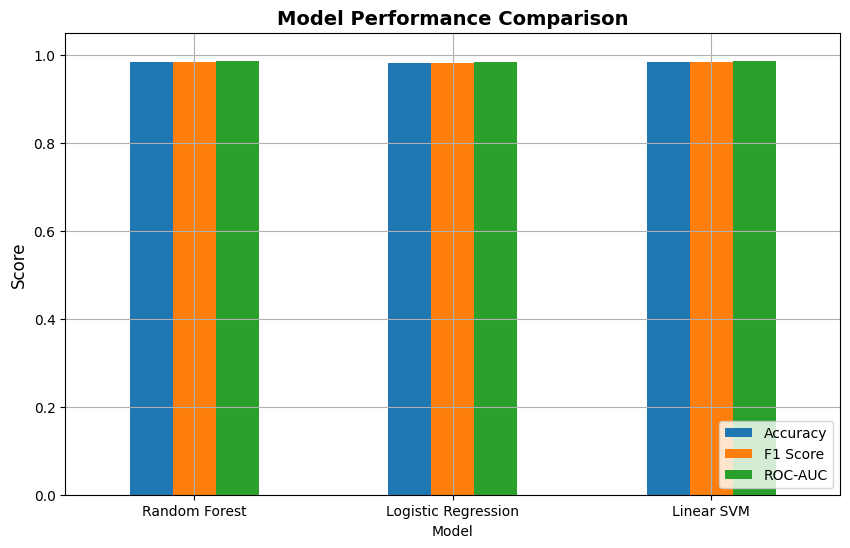


✅ Model Comparison Graph Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/model_comparison_bar.png


In [10]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score
)

# ==============================
# MODEL METRICS
# ==============================

# RF
rf_acc = accuracy_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

# LR
y_prob_lr = lr_model.predict_proba(
    X_test
)[:, 1]

y_pred_lr = lr_model.predict(
    X_test
)

lr_acc = accuracy_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

# SVM
y_prob_svm = svm_model.predict_proba(
    X_test
)[:, 1]

y_pred_svm = svm_model.predict(
    X_test
)

svm_acc = accuracy_score(
    y_test,
    y_pred_svm
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm
)

svm_auc = roc_auc_score(
    y_test,
    y_prob_svm
)

# ==============================
# DATAFRAME
# ==============================

comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression",
        "Linear SVM"
    ],

    "Accuracy": [
        rf_acc,
        lr_acc,
        svm_acc
    ],

    "F1 Score": [
        rf_f1,
        lr_f1,
        svm_f1
    ],

    "ROC-AUC": [
        rf_auc,
        lr_auc,
        svm_auc
    ]
})

print("\nModel Comparison:")
print(comparison_df)

# ==============================
# PLOT
# ==============================

comparison_df.set_index(
    "Model"
).plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Model Performance Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Score",
    fontsize=12
)

plt.ylim(0, 1.05)

plt.grid(True)

plt.xticks(rotation=0)

plt.legend(
    loc="lower right"
)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/model_comparison_bar.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Model Comparison Graph Saved:\n{save_path}"
)

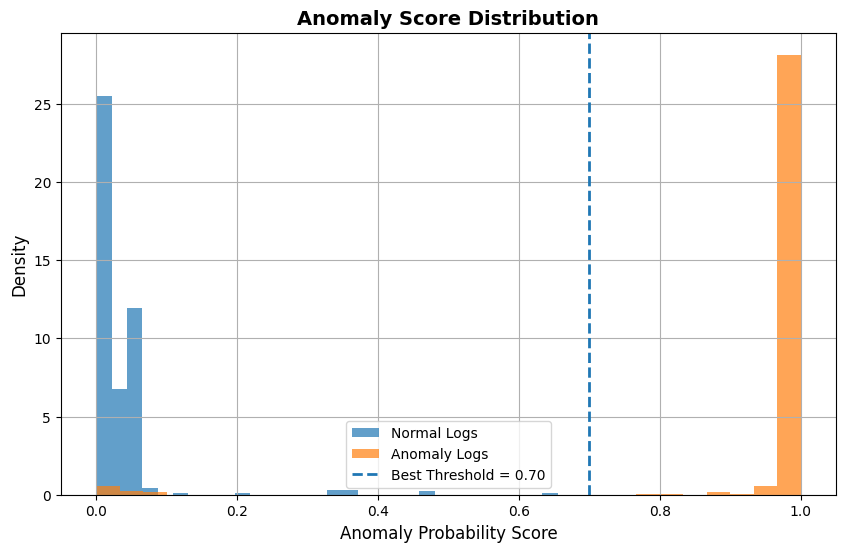


✅ Anomaly Score Distribution Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/anomaly_score_distribution.png


In [11]:
# ==============================
# ANOMALY SCORE DISTRIBUTION
# ==============================

# RF anomaly probabilities
y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

# Separate scores
normal_scores = y_prob_rf[
    y_test == 0
]

anomaly_scores = y_prob_rf[
    y_test == 1
]

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(10, 6))

plt.hist(
    normal_scores,
    bins=30,
    alpha=0.7,
    density=True,
    label="Normal Logs"
)

plt.hist(
    anomaly_scores,
    bins=30,
    alpha=0.7,
    density=True,
    label="Anomaly Logs"
)

plt.axvline(
    0.70,
    linestyle="--",
    linewidth=2,
    label="Best Threshold = 0.70"
)

plt.xlabel(
    "Anomaly Probability Score",
    fontsize=12
)

plt.ylabel(
    "Density",
    fontsize=12
)

plt.title(
    "Anomaly Score Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(True)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/anomaly_score_distribution.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Anomaly Score Distribution Saved:\n{save_path}"
)

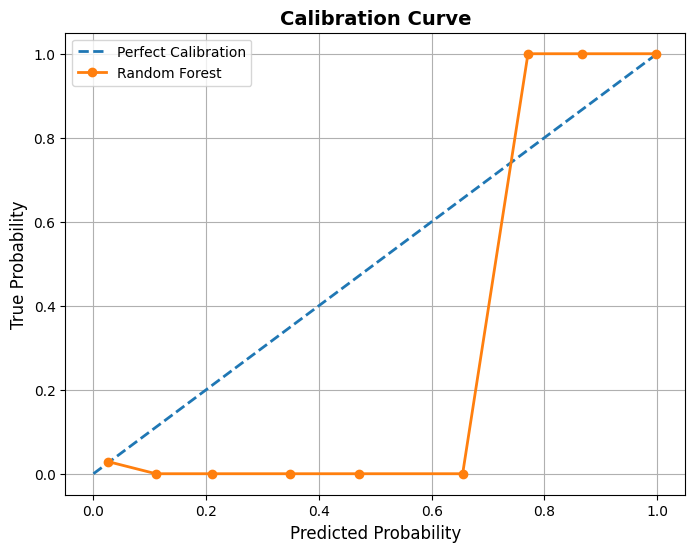


✅ Calibration Curve Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/calibration_curve_rf.png


In [12]:
from sklearn.calibration import calibration_curve

# ==============================
# CALIBRATION CURVE
# ==============================

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob_rf,
    n_bins=10
)

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(8, 6))

# Perfect calibration line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Perfect Calibration"
)

# RF calibration
plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    linewidth=2,
    label="Random Forest"
)

plt.xlabel(
    "Predicted Probability",
    fontsize=12
)

plt.ylabel(
    "True Probability",
    fontsize=12
)

plt.title(
    "Calibration Curve",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(True)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/calibration_curve_rf.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Calibration Curve Saved:\n{save_path}"
)

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ==============================
# LOAD DATA
# ==============================

X = sparse.load_npz(
    "E:/LogAnomalyDetector/data/processed/X_features.npz"
)

metadata = pd.read_csv(
    "E:/LogAnomalyDetector/data/processed/y_labels.csv"
)

y = metadata["true_label"].values

# ==============================
# FIXED NUMPY BOOLEAN MASKS
# ==============================

hdfs_mask = (
    metadata["source_dataset"]
    .values == "hdfs"
)

bgl_mask = (
    metadata["source_dataset"]
    .values == "bgl"
)

print("HDFS Samples:", hdfs_mask.sum())

print("BGL Samples:", bgl_mask.sum())

# ==============================
# HDFS -> BGL
# ==============================

X_train_cross = X[hdfs_mask]

y_train_cross = y[hdfs_mask]

X_test_cross = X[bgl_mask]

y_test_cross = y[bgl_mask]

cross_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("\nTraining RF on HDFS only...")

cross_rf.fit(
    X_train_cross,
    y_train_cross
)

print("\nTesting RF on BGL only...")

y_pred_cross = cross_rf.predict(
    X_test_cross
)

hdfs_to_bgl_acc = accuracy_score(
    y_test_cross,
    y_pred_cross
)

print(
    f"\nHDFS → BGL Accuracy: "
    f"{hdfs_to_bgl_acc:.4f}"
)

# ==============================
# BGL -> HDFS
# ==============================

X_train_bgl = X[bgl_mask]

y_train_bgl = y[bgl_mask]

X_test_hdfs = X[hdfs_mask]

y_test_hdfs = y[hdfs_mask]

reverse_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("\nTraining RF on BGL only...")

reverse_rf.fit(
    X_train_bgl,
    y_train_bgl
)

print("\nTesting RF on HDFS only...")

y_pred_reverse = reverse_rf.predict(
    X_test_hdfs
)

bgl_to_hdfs_acc = accuracy_score(
    y_test_hdfs,
    y_pred_reverse
)

print(
    f"\nBGL → HDFS Accuracy: "
    f"{bgl_to_hdfs_acc:.4f}"
)

print("\n✅ Cross-Dataset Evaluation Ready")

HDFS Samples: 2000
BGL Samples: 2000

Training RF on HDFS only...

Testing RF on BGL only...

HDFS → BGL Accuracy: 0.5705

Training RF on BGL only...

Testing RF on HDFS only...

BGL → HDFS Accuracy: 0.0345

✅ Cross-Dataset Evaluation Ready



Cross-Dataset Results:
       Scenario  Accuracy
0  Same Dataset   0.98375
1    HDFS → BGL   0.57050
2    BGL → HDFS   0.03450


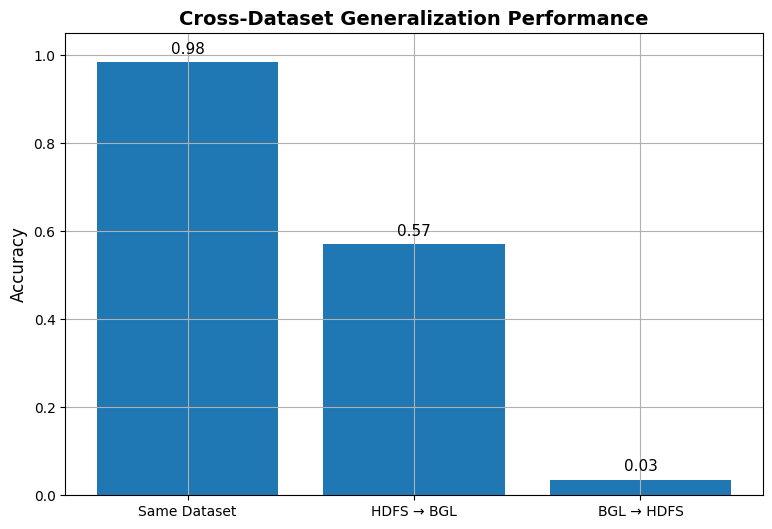


✅ Cross-Dataset Graph Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/cross_dataset_performance.png


In [16]:
# ==============================
# CROSS-DATASET PERFORMANCE
# ==============================

# Same-dataset RF
same_dataset_acc = accuracy_score(
    y_test,
    y_pred_rf
)

# HDFS -> BGL
hdfs_to_bgl_acc = accuracy_score(
    y_test_cross,
    y_pred_cross
)

# BGL -> HDFS
bgl_to_hdfs_acc = accuracy_score(
    y_test_hdfs,
    y_pred_reverse
)

# ==============================
# DATAFRAME
# ==============================

cross_df = pd.DataFrame({

    "Scenario": [
        "Same Dataset",
        "HDFS → BGL",
        "BGL → HDFS"
    ],

    "Accuracy": [
        same_dataset_acc,
        hdfs_to_bgl_acc,
        bgl_to_hdfs_acc
    ]
})

print("\nCross-Dataset Results:")
print(cross_df)

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(9, 6))

bars = plt.bar(
    cross_df["Scenario"],
    cross_df["Accuracy"]
)

plt.ylim(0, 1.05)

plt.ylabel(
    "Accuracy",
    fontsize=12
)

plt.title(
    "Cross-Dataset Generalization Performance",
    fontsize=14,
    fontweight="bold"
)

plt.grid(True)

# ==============================
# VALUE LABELS
# ==============================

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha='center',
        fontsize=11
    )

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/cross_dataset_performance.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Cross-Dataset Graph Saved:\n{save_path}"
)


Dataset Distribution:
source_dataset
hdfs    2000
bgl     2000
Name: count, dtype: int64


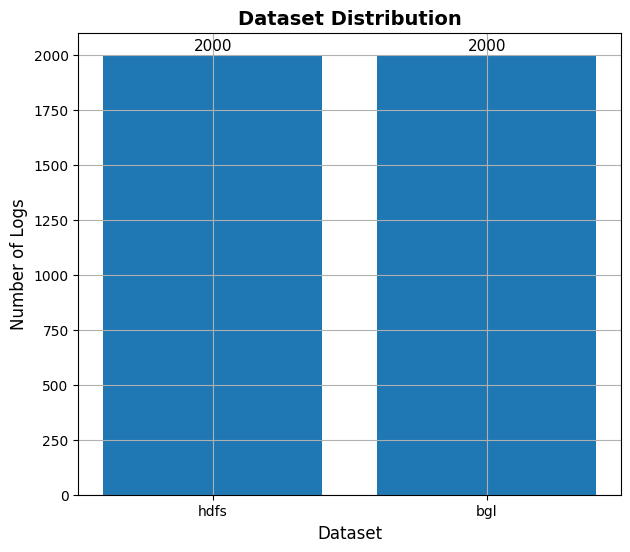


✅ Dataset Distribution Graph Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/dataset_distribution.png


In [17]:
# ==============================
# DATASET DISTRIBUTION
# ==============================

dataset_counts = (
    metadata["source_dataset"]
    .value_counts()
)

print("\nDataset Distribution:")
print(dataset_counts)

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(7, 6))

bars = plt.bar(
    dataset_counts.index,
    dataset_counts.values
)

plt.xlabel(
    "Dataset",
    fontsize=12
)

plt.ylabel(
    "Number of Logs",
    fontsize=12
)

plt.title(
    "Dataset Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.grid(True)

# ==============================
# VALUE LABELS
# ==============================

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{height}",
        ha="center",
        fontsize=11
    )

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/dataset_distribution.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Dataset Distribution Graph Saved:\n{save_path}"
)


Label Distribution:
true_label
0    2074
1    1926
Name: count, dtype: int64


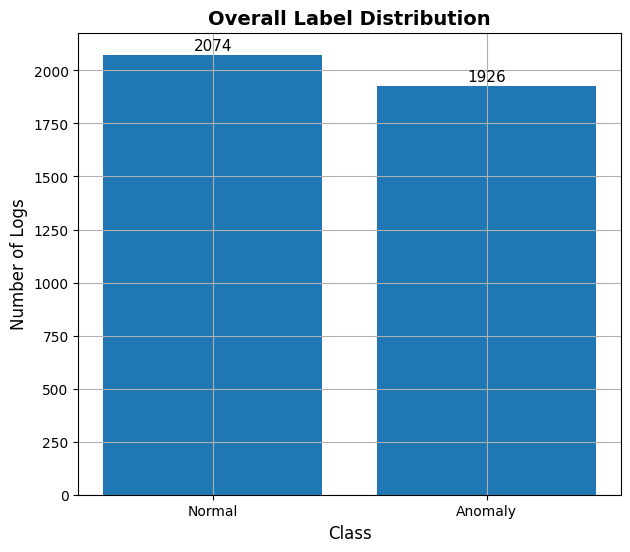


✅ Label Distribution Graph Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/label_distribution.png


In [18]:
# ==============================
# LABEL DISTRIBUTION
# ==============================

label_counts = (
    metadata["true_label"]
    .value_counts()
)

print("\nLabel Distribution:")
print(label_counts)

# ==============================
# LABEL MAPPING
# ==============================

label_names = {
    0: "Normal",
    1: "Anomaly"
}

labels = [
    label_names[i]
    for i in label_counts.index
]

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(7, 6))

bars = plt.bar(
    labels,
    label_counts.values
)

plt.xlabel(
    "Class",
    fontsize=12
)

plt.ylabel(
    "Number of Logs",
    fontsize=12
)

plt.title(
    "Overall Label Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.grid(True)

# ==============================
# VALUE LABELS
# ==============================

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{height}",
        ha="center",
        fontsize=11
    )

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/label_distribution.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Label Distribution Graph Saved:\n{save_path}"
)


Dataset-wise Label Distribution:
true_label         0     1
source_dataset            
bgl              143  1857
hdfs            1931    69


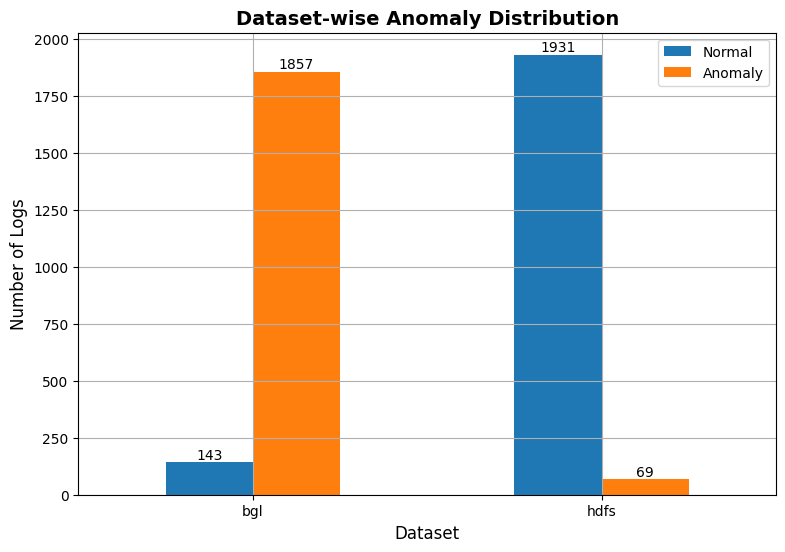


✅ Dataset-wise Distribution Graph Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/dataset_wise_label_distribution.png


In [19]:
# ==============================
# DATASET-WISE LABEL DISTRIBUTION
# ==============================

dataset_label_dist = pd.crosstab(
    metadata["source_dataset"],
    metadata["true_label"]
)

print("\nDataset-wise Label Distribution:")
print(dataset_label_dist)

# ==============================
# RENAME COLUMNS
# ==============================

dataset_label_dist.columns = [
    "Normal",
    "Anomaly"
]

# ==============================
# PLOT
# ==============================

ax = dataset_label_dist.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.xlabel(
    "Dataset",
    fontsize=12
)

plt.ylabel(
    "Number of Logs",
    fontsize=12
)

plt.title(
    "Dataset-wise Anomaly Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=0)

plt.grid(True)

# ==============================
# VALUE LABELS
# ==============================

for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=10
    )

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/dataset_wise_label_distribution.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Dataset-wise Distribution Graph Saved:\n{save_path}"
)

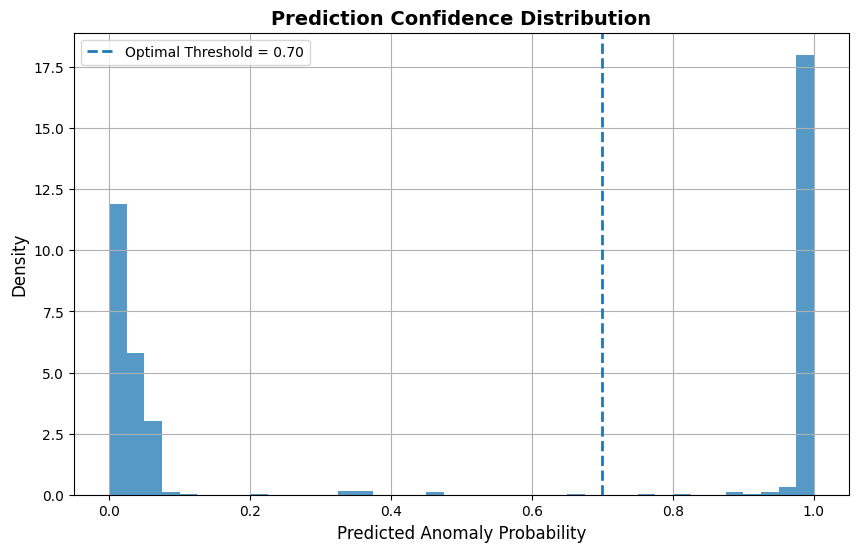


✅ Probability Distribution Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/probability_confidence_distribution.png


In [20]:
# ==============================
# PROBABILITY CONFIDENCE DISTRIBUTION
# ==============================

# RF probabilities
y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(10, 6))

plt.hist(
    y_prob_rf,
    bins=40,
    density=True,
    alpha=0.75
)

plt.axvline(
    0.70,
    linestyle="--",
    linewidth=2,
    label="Optimal Threshold = 0.70"
)

plt.xlabel(
    "Predicted Anomaly Probability",
    fontsize=12
)

plt.ylabel(
    "Density",
    fontsize=12
)

plt.title(
    "Prediction Confidence Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(True)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/probability_confidence_distribution.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Probability Distribution Saved:\n{save_path}"
)


Structured Feature Correlation:
                     message_length  token_count  digit_ratio  \
message_length             1.000000          NaN          NaN   
token_count                     NaN          NaN          NaN   
digit_ratio                     NaN          NaN          NaN   
uppercase_ratio            0.020220          NaN          NaN   
special_char_count              NaN          NaN          NaN   
numeric_token_count       -0.015041          NaN          NaN   
unique_token_ratio        -0.147874          NaN          NaN   
contains_ip               -0.022301          NaN          NaN   
contains_url               0.013801          NaN          NaN   
contains_path              0.016333          NaN          NaN   
contains_port                   NaN          NaN          NaN   
contains_hex               0.050894          NaN          NaN   
contains_failure          -1.000000          NaN          NaN   
contains_exception         0.162171          NaN         

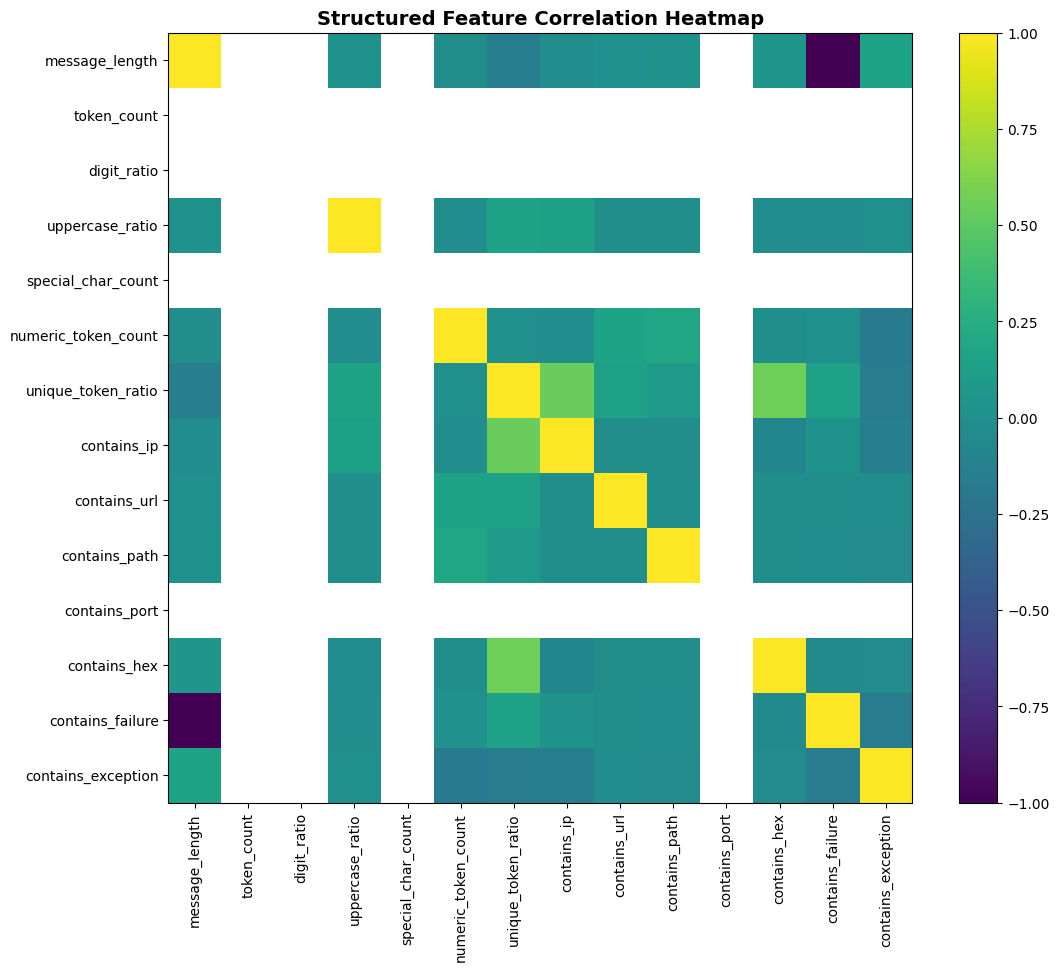


✅ Feature Correlation Heatmap Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/feature_correlation_heatmap.png


In [21]:
# ==============================
# STRUCTURED FEATURE CORRELATION
# ==============================

structured_feature_names = [

    "message_length",
    "token_count",
    "digit_ratio",
    "uppercase_ratio",
    "special_char_count",
    "numeric_token_count",
    "unique_token_ratio",

    "contains_ip",
    "contains_url",
    "contains_path",
    "contains_port",
    "contains_hex",

    "contains_failure",
    "contains_exception"
]

# ==============================
# EXTRACT STRUCTURED FEATURES
# ==============================

structured_feature_count = len(
    structured_feature_names
)

structured_matrix = X[:, -structured_feature_count:]

structured_dense = (
    structured_matrix
    .toarray()
)

structured_df = pd.DataFrame(
    structured_dense,
    columns=structured_feature_names
)

# ==============================
# CORRELATION MATRIX
# ==============================

corr_matrix = structured_df.corr()

print("\nStructured Feature Correlation:")
print(corr_matrix)

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(12, 10))

plt.imshow(
    corr_matrix,
    aspect='auto'
)

plt.colorbar()

plt.xticks(
    range(len(structured_feature_names)),
    structured_feature_names,
    rotation=90
)

plt.yticks(
    range(len(structured_feature_names)),
    structured_feature_names
)

plt.title(
    "Structured Feature Correlation Heatmap",
    fontsize=14,
    fontweight="bold"
)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/feature_correlation_heatmap.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Feature Correlation Heatmap Saved:\n{save_path}"
)

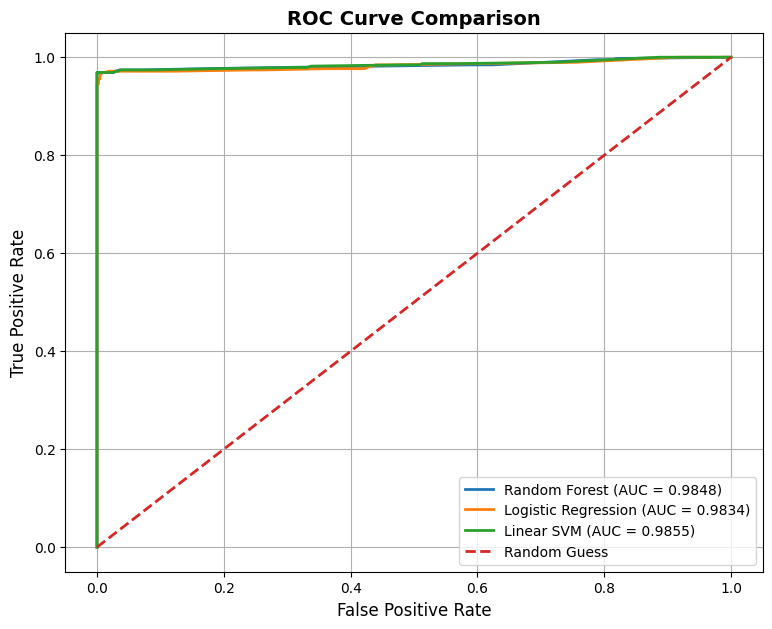


✅ ROC Comparison Graph Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/roc_curve_comparison.png


In [22]:
from sklearn.metrics import roc_curve, auc

# ==============================
# RF ROC
# ==============================

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

auc_rf = auc(
    fpr_rf,
    tpr_rf
)

# ==============================
# LR ROC
# ==============================

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

auc_lr = auc(
    fpr_lr,
    tpr_lr
)

# ==============================
# SVM ROC
# ==============================

fpr_svm, tpr_svm, _ = roc_curve(
    y_test,
    y_prob_svm
)

auc_svm = auc(
    fpr_svm,
    tpr_svm
)

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {auc_rf:.4f})"
)

plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_lr:.4f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    linewidth=2,
    label=f"Linear SVM (AUC = {auc_svm:.4f})"
)

# Random baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Guess"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "ROC Curve Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    loc="lower right"
)

plt.grid(True)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/roc_curve_comparison.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ ROC Comparison Graph Saved:\n{save_path}"
)


Explained Variance Ratio:
[0.19216449 0.17208952]


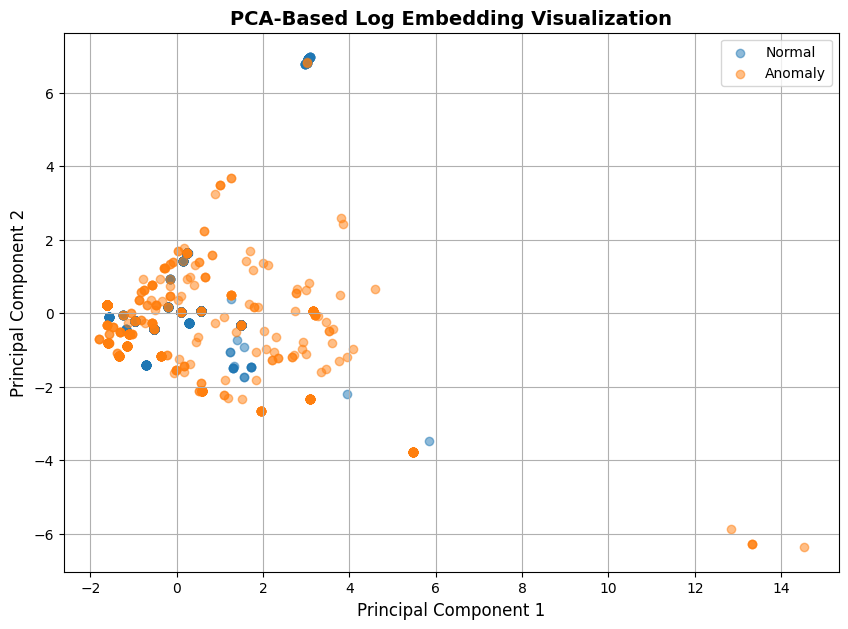


✅ PCA Visualization Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/pca_embedding_visualization.png


In [23]:
from sklearn.decomposition import PCA

# ==============================
# SAMPLE DATA FOR VISUALIZATION
# ==============================

sample_size = 2000

indices = np.random.choice(
    X.shape[0],
    sample_size,
    replace=False
)

X_sample = X[indices]

y_sample = y[indices]

# ==============================
# CONVERT TO DENSE
# ==============================

X_dense = X_sample.toarray()

# ==============================
# PCA REDUCTION
# ==============================

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_dense
)

print(
    "\nExplained Variance Ratio:"
)

print(
    pca.explained_variance_ratio_
)

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(10, 7))

normal_mask = (
    y_sample == 0
)

anomaly_mask = (
    y_sample == 1
)

plt.scatter(
    X_pca[normal_mask, 0],
    X_pca[normal_mask, 1],
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    X_pca[anomaly_mask, 0],
    X_pca[anomaly_mask, 1],
    alpha=0.5,
    label="Anomaly"
)

plt.xlabel(
    "Principal Component 1",
    fontsize=12
)

plt.ylabel(
    "Principal Component 2",
    fontsize=12
)

plt.title(
    "PCA-Based Log Embedding Visualization",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(True)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/pca_embedding_visualization.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ PCA Visualization Saved:\n{save_path}"
)


✅ t-SNE Projection Complete


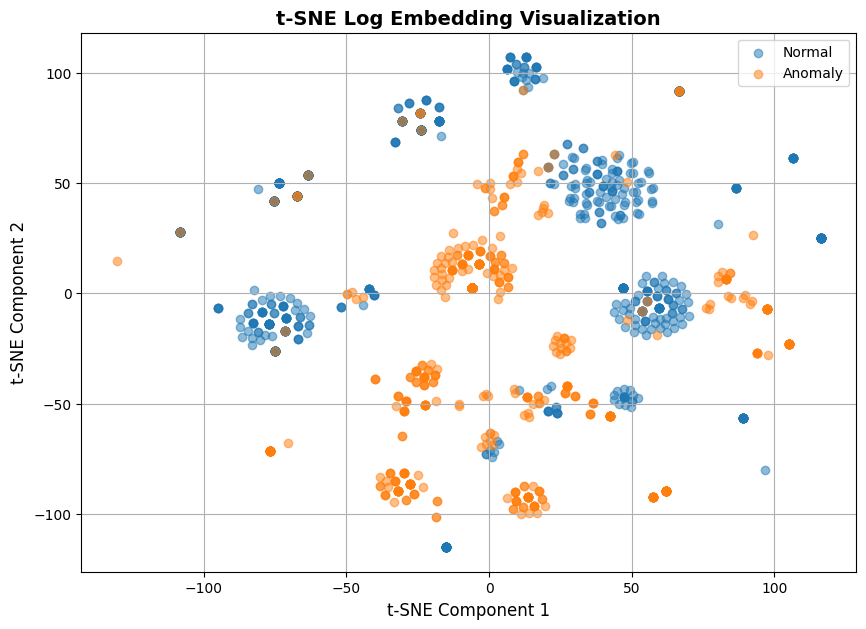


✅ t-SNE Visualization Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/tsne_embedding_visualization.png


In [24]:
from sklearn.manifold import TSNE

# ==============================
# SAMPLE DATA
# ==============================

sample_size = 1500

indices = np.random.choice(
    X.shape[0],
    sample_size,
    replace=False
)

X_sample = X[indices]

y_sample = y[indices]

# ==============================
# CONVERT TO DENSE
# ==============================

X_dense = X_sample.toarray()

# ==============================
# t-SNE REDUCTION
# ==============================

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(
    X_dense
)

print(
    "\n✅ t-SNE Projection Complete"
)

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(10, 7))

normal_mask = (
    y_sample == 0
)

anomaly_mask = (
    y_sample == 1
)

plt.scatter(
    X_tsne[normal_mask, 0],
    X_tsne[normal_mask, 1],
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    X_tsne[anomaly_mask, 0],
    X_tsne[anomaly_mask, 1],
    alpha=0.5,
    label="Anomaly"
)

plt.xlabel(
    "t-SNE Component 1",
    fontsize=12
)

plt.ylabel(
    "t-SNE Component 2",
    fontsize=12
)

plt.title(
    "t-SNE Log Embedding Visualization",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(True)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/tsne_embedding_visualization.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ t-SNE Visualization Saved:\n{save_path}"
)

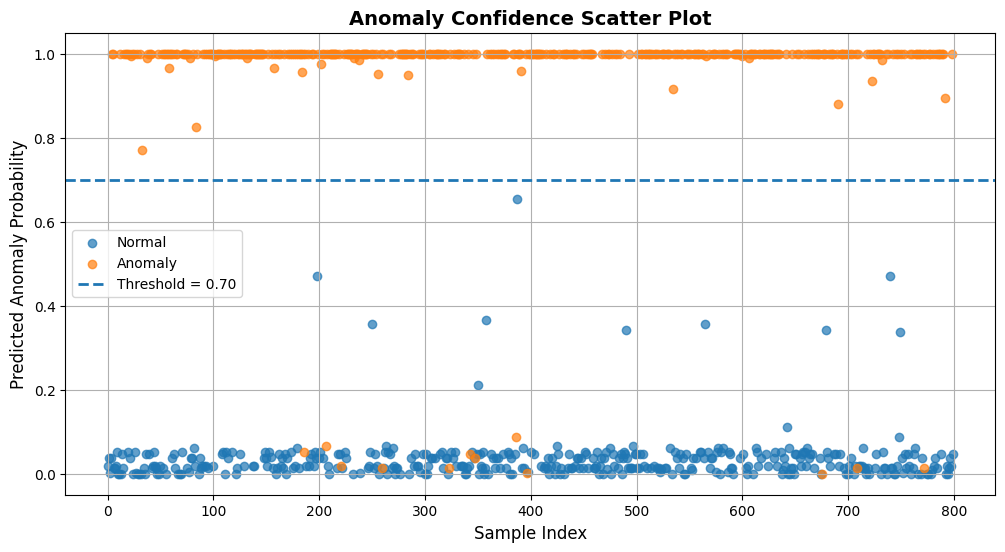


✅ Confidence Scatter Plot Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/anomaly_confidence_scatter.png


In [25]:
# ==============================
# ANOMALY CONFIDENCE SCATTER
# ==============================

sample_size = 800

indices = np.random.choice(
    len(y_test),
    sample_size,
    replace=False
)

sample_probs = y_prob_rf[indices]

sample_labels = y_test[indices]

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(12, 6))

normal_idx = (
    sample_labels == 0
)

anomaly_idx = (
    sample_labels == 1
)

plt.scatter(
    np.arange(sample_size)[normal_idx],
    sample_probs[normal_idx],
    alpha=0.7,
    label="Normal"
)

plt.scatter(
    np.arange(sample_size)[anomaly_idx],
    sample_probs[anomaly_idx],
    alpha=0.7,
    label="Anomaly"
)

# Threshold
plt.axhline(
    0.70,
    linestyle="--",
    linewidth=2,
    label="Threshold = 0.70"
)

plt.xlabel(
    "Sample Index",
    fontsize=12
)

plt.ylabel(
    "Predicted Anomaly Probability",
    fontsize=12
)

plt.title(
    "Anomaly Confidence Scatter Plot",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(True)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/anomaly_confidence_scatter.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Confidence Scatter Plot Saved:\n{save_path}"
)

In [28]:
# ==============================
# LOAD TF-IDF VECTORIZER
# ==============================

vectorizer = joblib.load(
    "E:/LogAnomalyDetector/models/tfidf_vectorizer.joblib"
)

print("✅ TF-IDF Vectorizer Loaded")

✅ TF-IDF Vectorizer Loaded


✅ TF-IDF Vectorizer Loaded

Feature Count: 1324
Importance Count: 1324

Top Important Features:
                 feature  importance
102                block    0.090098
107             block_id    0.069064
1310      message_length    0.055187
723                  num    0.048317
1313     uppercase_ratio    0.042973
104       block block_id    0.040570
1314  special_char_count    0.037014
766              num num    0.034711
1311         token_count    0.020779
188                 core    0.018131
191             core num    0.017595
450      generating core    0.015908
105     block namesystem    0.012744
691           namesystem    0.012660
449           generating    0.012467


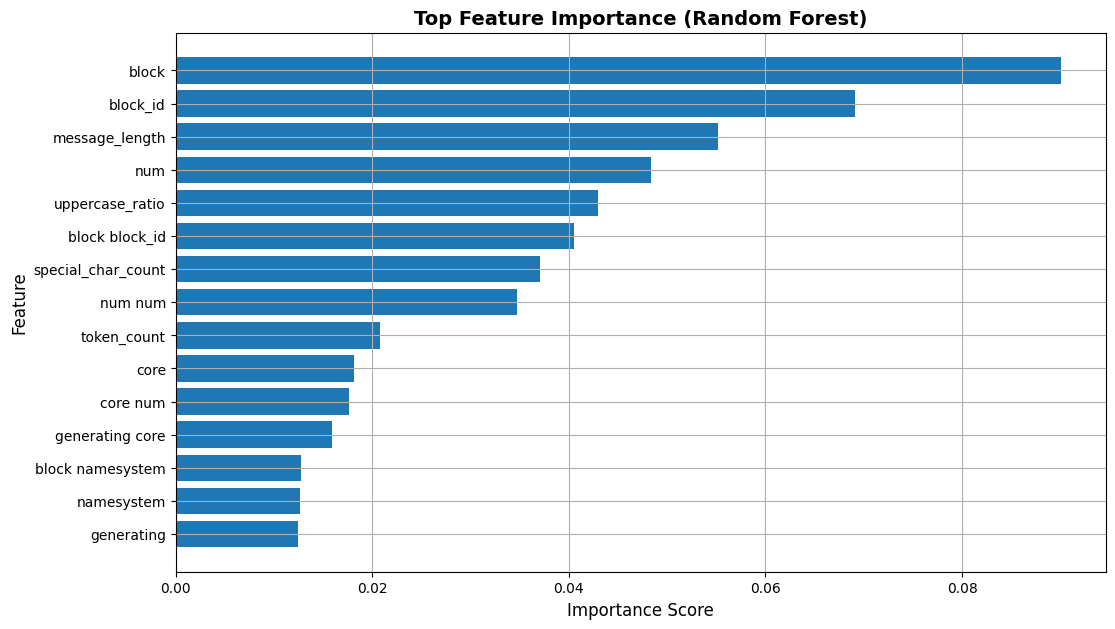


✅ Feature Importance Graph Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/feature_importance_bargraph.png


In [30]:
# ==============================
# LOAD TF-IDF VECTORIZER
# ==============================

vectorizer = joblib.load(
    "E:/LogAnomalyDetector/models/tfidf_vectorizer.joblib"
)

print("✅ TF-IDF Vectorizer Loaded")

# ==============================
# TF-IDF FEATURE NAMES
# ==============================

tfidf_feature_names = list(
    vectorizer.get_feature_names_out()
)

# ==============================
# STRUCTURED FEATURE NAMES
# ==============================

structured_feature_names = [

    "message_length",
    "token_count",
    "digit_ratio",
    "uppercase_ratio",
    "special_char_count",
    "numeric_token_count",
    "unique_token_ratio",

    "contains_ip",
    "contains_url",
    "contains_path",
    "contains_port",
    "contains_hex",

    "contains_failure",
    "contains_exception"
]

# ==============================
# COMBINE FEATURES
# ==============================

all_feature_names = (
    tfidf_feature_names
    + structured_feature_names
)

# ==============================
# RF IMPORTANCES
# ==============================

importances = (
    rf_model.feature_importances_
)

# ==============================
# SAFETY ALIGNMENT FIX
# ==============================

min_len = min(
    len(all_feature_names),
    len(importances)
)

all_feature_names = (
    all_feature_names[:min_len]
)

importances = (
    importances[:min_len]
)

print(
    "\nFeature Count:",
    len(all_feature_names)
)

print(
    "Importance Count:",
    len(importances)
)

# ==============================
# DATAFRAME
# ==============================

importance_df = pd.DataFrame({

    "feature": all_feature_names,
    "importance": importances
})

# ==============================
# TOP FEATURES
# ==============================

top_features = (
    importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
    .head(15)
)

print("\nTop Important Features:")
print(top_features)

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(12, 7))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel(
    "Importance Score",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.title(
    "Top Feature Importance (Random Forest)",
    fontsize=14,
    fontweight="bold"
)

plt.grid(True)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/feature_importance_bargraph.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Feature Importance Graph Saved:\n{save_path}"
)


Model Performance Summary:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0        Random Forest   0.98375   0.997326  0.968831  0.982872  0.984797
1  Logistic Regression   0.98125   0.994652  0.966234  0.980237  0.983399
2           Linear SVM   0.98375   0.997326  0.968831  0.982872  0.985508


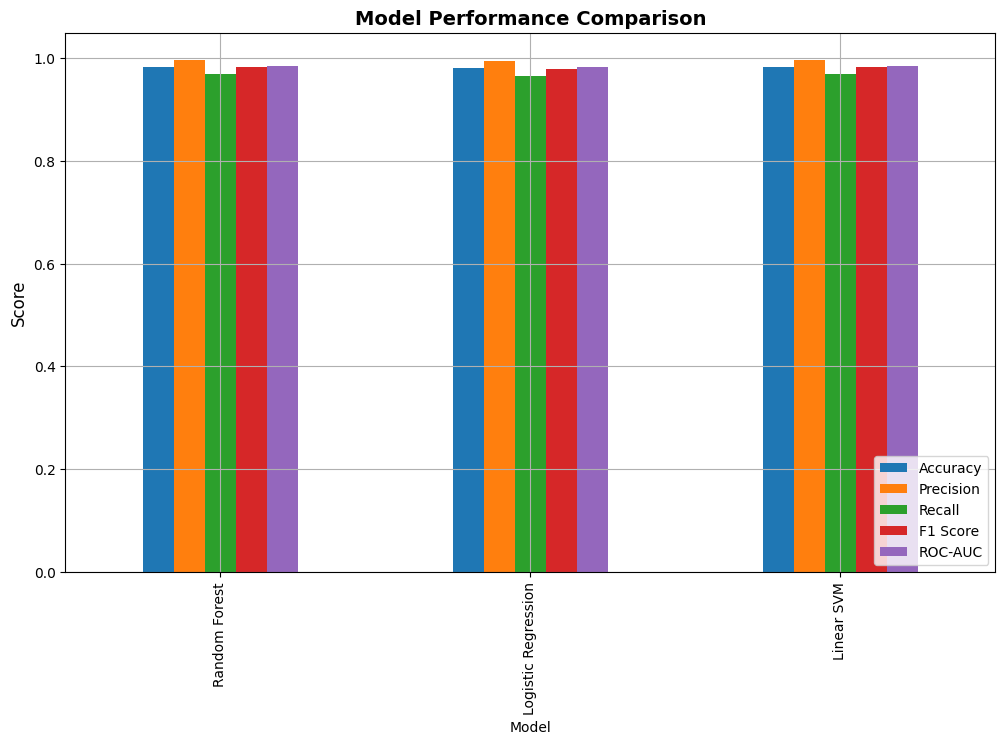


✅ Model Summary Graph Saved:
E:/LogAnomalyDetector/notebooks/graphs/advanced_evaluation/model_performance_summary.png


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ==============================
# RANDOM FOREST METRICS
# ==============================

rf_acc = accuracy_score(
    y_test,
    y_pred_rf
)

rf_prec = precision_score(
    y_test,
    y_pred_rf
)

rf_rec = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

# ==============================
# LOGISTIC REGRESSION METRICS
# ==============================

lr_acc = accuracy_score(
    y_test,
    y_pred_lr
)

lr_prec = precision_score(
    y_test,
    y_pred_lr
)

lr_rec = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

# ==============================
# SVM METRICS
# ==============================

svm_acc = accuracy_score(
    y_test,
    y_pred_svm
)

svm_prec = precision_score(
    y_test,
    y_pred_svm
)

svm_rec = recall_score(
    y_test,
    y_pred_svm
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm
)

svm_auc = roc_auc_score(
    y_test,
    y_prob_svm
)

# ==============================
# SUMMARY DATAFRAME
# ==============================

summary_df = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Logistic Regression",
        "Linear SVM"
    ],

    "Accuracy": [
        rf_acc,
        lr_acc,
        svm_acc
    ],

    "Precision": [
        rf_prec,
        lr_prec,
        svm_prec
    ],

    "Recall": [
        rf_rec,
        lr_rec,
        svm_rec
    ],

    "F1 Score": [
        rf_f1,
        lr_f1,
        svm_f1
    ],

    "ROC-AUC": [
        rf_auc,
        lr_auc,
        svm_auc
    ]
})

print("\nModel Performance Summary:")
print(summary_df)

# ==============================
# PLOT
# ==============================

summary_df_plot = (
    summary_df
    .set_index("Model")
)

summary_df_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.ylabel(
    "Score",
    fontsize=12
)

plt.title(
    "Model Performance Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylim(0, 1.05)

plt.grid(True)

plt.legend(
    loc="lower right"
)

# ==============================
# SAVE
# ==============================

save_path = (
    f"{GRAPH_DIR}/model_performance_summary.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Model Summary Graph Saved:\n{save_path}"
)

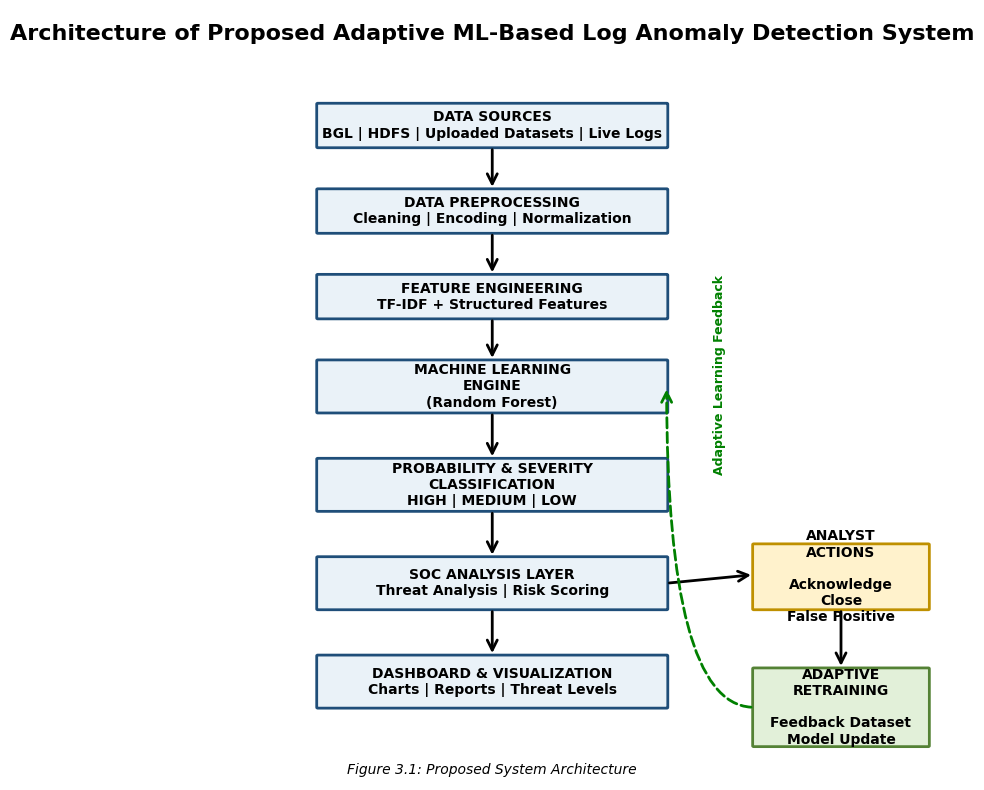

Saved Successfully:
Figure_3_1_Proposed_System_Architecture.png
Figure_3_1_Proposed_System_Architecture.pdf


E:\LogAnomalyDetector\notebooks\graphs\Figure_3_1_Proposed_System_Architecture.png

E:\LogAnomalyDetector\notebooks\graphs\Figure_3_1_Proposed_System_Architecture.pdf

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import FileLink, display

# ==========================================================
# CANVAS
# ==========================================================

fig, ax = plt.subplots(figsize=(12,10))
ax.set_xlim(0,16)
ax.set_ylim(0,18)
ax.axis('off')

# ==========================================================
# TITLE
# ==========================================================

ax.text(
    8,
    17.3,
    "Architecture of Proposed Adaptive ML-Based Log Anomaly Detection System",
    fontsize=16,
    fontweight='bold',
    ha='center'
)

# ==========================================================
# BOX FUNCTION
# ==========================================================

def draw_box(x, y, w, h, text,
             face='#EAF2F8',
             edge='#1F4E79'):

    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02",
        linewidth=2,
        edgecolor=edge,
        facecolor=face
    )

    ax.add_patch(box)

    ax.text(
        x + w/2,
        y + h/2,
        text,
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# ==========================================================
# MAIN PIPELINE
# ==========================================================

draw_box(
    5,14.8,
    6,1,
    "DATA SOURCES\nBGL | HDFS | Uploaded Datasets | Live Logs"
)

draw_box(
    5,12.8,
    6,1,
    "DATA PREPROCESSING\nCleaning | Encoding | Normalization"
)

draw_box(
    5,10.8,
    6,1,
    "FEATURE ENGINEERING\nTF-IDF + Structured Features"
)

draw_box(
    5,8.6,
    6,1.2,
    "MACHINE LEARNING\nENGINE\n(Random Forest)"
)

draw_box(
    5,6.3,
    6,1.2,
    "PROBABILITY & SEVERITY\nCLASSIFICATION\nHIGH | MEDIUM | LOW"
)

draw_box(
    5,4,
    6,1.2,
    "SOC ANALYSIS LAYER\nThreat Analysis | Risk Scoring"
)

draw_box(
    5,1.7,
    6,1.2,
    "DASHBOARD & VISUALIZATION\nCharts | Reports | Threat Levels"
)

# ==========================================================
# ANALYST ACTIONS
# ==========================================================

draw_box(
    12.5,4,
    3,
    1.5,
    "ANALYST\nACTIONS\n\nAcknowledge\nClose\nFalse Positive",
    face="#FFF2CC",
    edge="#BF9000"
)

# ==========================================================
# ADAPTIVE RETRAINING
# ==========================================================

draw_box(
    12.5,0.8,
    3,
    1.8,
    "ADAPTIVE\nRETRAINING\n\nFeedback Dataset\nModel Update",
    face="#E2F0D9",
    edge="#548235"
)

# ==========================================================
# ARROW FUNCTION
# ==========================================================

def arrow(x1,y1,x2,y2):

    ax.add_patch(
        FancyArrowPatch(
            (x1,y1),
            (x2,y2),
            arrowstyle='->',
            mutation_scale=18,
            linewidth=2,
            color='black'
        )
    )

# ==========================================================
# MAIN FLOW
# ==========================================================

arrow(8,14.8,8,13.8)
arrow(8,12.8,8,11.8)
arrow(8,10.8,8,9.8)
arrow(8,8.6,8,7.5)
arrow(8,6.3,8,5.2)
arrow(8,4,8,2.9)

# ==========================================================
# SOC -> ANALYST
# ==========================================================

arrow(
    11,
    4.6,
    12.5,
    4.8
)

# ==========================================================
# ANALYST -> RETRAINING
# ==========================================================

arrow(
    14,
    4,
    14,
    2.6
)

# ==========================================================
# RETRAINING -> ML ENGINE
# ==========================================================

feedback_arrow = FancyArrowPatch(
    (12.5,1.7),
    (11,9.2),
    arrowstyle='->',
    mutation_scale=18,
    linewidth=2,
    linestyle='--',
    color='green',
    connectionstyle="angle3,angleA=180,angleB=90"
)

ax.add_patch(feedback_arrow)

ax.text(
    11.8,
    7.2,
    "Adaptive Learning Feedback",
    fontsize=9,
    color='green',
    fontweight='bold',
    rotation=90
)

# ==========================================================
# FIGURE LABEL
# ==========================================================

ax.text(
    8,
    0.15,
    "Figure 3.1: Proposed System Architecture",
    fontsize=10,
    style='italic',
    ha='center'
)

# ==========================================================
# SAVE
# ==========================================================

png_file = "Figure_3_1_Proposed_System_Architecture.png"
pdf_file = "Figure_3_1_Proposed_System_Architecture.pdf"

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    pdf_file,
    bbox_inches='tight'
)

plt.show()

print("Saved Successfully:")
print(png_file)
print(pdf_file)

display(FileLink(png_file))
display(FileLink(pdf_file))

In [1]:
from graphviz import Digraph

# Create workflow diagram
dot = Digraph("Workflow", format="png")

# Professional styling
dot.attr(rankdir="TB")
dot.attr(
    "node",
    shape="box",
    style="rounded",
    fontname="Times New Roman",
    fontsize="12",
    margin="0.2,0.1"
)

dot.attr(
    "edge",
    fontname="Times New Roman",
    fontsize="10"
)

# Workflow nodes

dot.node("A", "Data Sources\n(HDFS, BGL, ADFA-LD,\nLive Logs, Uploaded Datasets)")

dot.node("B", "Log Collection Layer")

dot.node("C", "Data Preprocessing\nand Normalization Layer")

dot.node("D", "Feature Engineering Layer\n(TF-IDF + Structured Features)")

dot.node("E", "Machine Learning\nDetection Engine\n(Random Forest)")

dot.node("F", "Severity Classification\nand Threat Scoring Layer")

dot.node("G", "Behavioral Correlation\nand Escalation Layer")

dot.node("H", "Deduplication and\nAlert Management Layer")

dot.node("I", "SOC Investigation\nand Response Layer")

dot.node("J", "Threat Intelligence,\nMITRE ATT&CK Mapping\nand Recommendation Engine")

dot.node("K", "Analyst Feedback\nCollection")

dot.node("L", "Controlled Retraining\nand Model Validation")

# Connections

dot.edge("A", "B")
dot.edge("B", "C")
dot.edge("C", "D")
dot.edge("D", "E")
dot.edge("E", "F")
dot.edge("F", "G")
dot.edge("G", "H")
dot.edge("H", "I")
dot.edge("I", "J")
dot.edge("J", "K")
dot.edge("K", "L")

# Feedback loop
dot.edge(
    "L",
    "E",
    label="Validated Model Update",
    style="dashed"
)

# Save
dot.render("adaptive_ml_system_workflow", cleanup=True)

print("Workflow diagram saved as adaptive_ml_system_workflow.png")


(process:13544): Pango-WARNING **: 10:38:09.894: couldn't load font "Times New Not-Rotated 12", falling back to "Sans Not-Rotated 12", expect ugly output.

(process:13544): Pango-WARNING **: 10:38:09.943: couldn't load font "Times New Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Workflow diagram saved as adaptive_ml_system_workflow.png


In [2]:
from graphviz import Digraph

dot = Digraph("Adaptive_ML_Workflow", format="png")

# High resolution
dot.attr(rankdir="TB")
dot.attr(splines="ortho")
dot.attr(nodesep="0.5")
dot.attr(ranksep="0.8")

# Global node style
dot.attr(
    "node",
    shape="box",
    style="rounded",
    fontname="Times New Roman",
    fontsize="12",
    margin="0.15,0.08"
)

# =====================================================
# DATA ACQUISITION LAYER
# =====================================================

with dot.subgraph(name="cluster_input") as c:
    c.attr(label="Data Acquisition Layer", fontsize="14", fontname="Times New Roman")
    c.node(
        "A",
        "Data Sources\n(HDFS, BGL, ADFA-LD,\nLive Logs,\nUploaded Datasets)"
    )

# =====================================================
# PROCESSING & DETECTION LAYER
# =====================================================

with dot.subgraph(name="cluster_processing") as c:
    c.attr(label="Processing and Detection Layer",
           fontsize="14",
           fontname="Times New Roman")

    c.node("B", "Log Collection")
    c.node("C", "Preprocessing\n& Normalization")
    c.node("D", "Feature Engineering\n(TF-IDF + Structured Features)")
    c.node("E", "Machine Learning\nDetection Engine\n(Random Forest)")

# =====================================================
# ANALYSIS LAYER
# =====================================================

with dot.subgraph(name="cluster_analysis") as c:
    c.attr(label="Threat Analysis Layer",
           fontsize="14",
           fontname="Times New Roman")

    c.node("F", "Severity Classification\n& Threat Scoring")
    c.node("G", "Behavioral Correlation\n& Escalation")
    c.node("H", "Deduplication\n& Alert Management")

# =====================================================
# SOC LAYER
# =====================================================

with dot.subgraph(name="cluster_soc") as c:
    c.attr(label="SOC Investigation Layer",
           fontsize="14",
           fontname="Times New Roman")

    c.node("I", "SOC Investigation\n& Response")
    c.node("J", "Threat Intelligence\nMITRE ATT&CK Mapping\n& Recommendations")

# =====================================================
# LEARNING LAYER
# =====================================================

with dot.subgraph(name="cluster_learning") as c:
    c.attr(label="Adaptive Learning Layer",
           fontsize="14",
           fontname="Times New Roman")

    c.node("K", "Analyst Feedback")
    c.node("L", "Controlled Retraining\n& Model Validation")

# =====================================================
# MAIN FLOW
# =====================================================

dot.edge("A", "B")

dot.edge("B", "C")
dot.edge("C", "D")
dot.edge("D", "E")

dot.edge("E", "F")
dot.edge("F", "G")
dot.edge("G", "H")

dot.edge("H", "I")
dot.edge("I", "J")

dot.edge("J", "K")
dot.edge("K", "L")

# =====================================================
# FEEDBACK LOOP
# =====================================================

dot.edge(
    "L",
    "E",
    label="Validated Model Update",
    style="dashed"
)

# =====================================================
# EXPORT
# =====================================================

dot.render("springer_workflow_diagram", cleanup=True)

print("Diagram saved as springer_workflow_diagram.png")


(process:3924): Pango-WARNING **: 10:41:29.415: couldn't load font "Times New Not-Rotated 12", falling back to "Sans Not-Rotated 12", expect ugly output.

(process:3924): Pango-WARNING **: 10:41:29.443: couldn't load font "Times New Not-Rotated 14", falling back to "Sans Not-Rotated 14", expect ugly output.


Diagram saved as springer_workflow_diagram.png


In [3]:
from graphviz import Digraph

dot = Digraph("SystemWorkflow", format="png")

# High quality
dot.attr(rankdir="TB")
dot.attr(splines="ortho")
dot.attr(nodesep="0.5")
dot.attr(ranksep="0.7")

dot.attr(
    "node",
    shape="box",
    style="rounded",
    fontname="Times New Roman",
    fontsize="12",
    margin="0.15,0.08"
)

# =====================================================
# INPUTS
# =====================================================

dot.node(
    "A",
    "Input Sources\n(Live Logs + Uploaded Datasets)"
)

# =====================================================
# PIPELINE
# =====================================================

dot.node("B", "Log Collection")
dot.node("C", "Preprocessing &\nNormalization")
dot.node("D", "Feature Engineering\n(TF-IDF + Structured Features)")
dot.node("E", "Random Forest\nDetection Engine")

# =====================================================
# ANALYSIS STAGE
# =====================================================

dot.node("F", "Severity Classification\n& Threat Scoring")
dot.node("G", "Behavioral Correlation\n& Escalation")
dot.node("H", "Deduplication &\nAlert Management")

# Put these on same horizontal level
dot.attr(rank="same")
with dot.subgraph() as s:
    s.attr(rank="same")
    s.node("F")
    s.node("G")
    s.node("H")

# =====================================================
# SOC
# =====================================================

dot.node("I", "SOC Investigation\n& Response")

dot.node(
    "J",
    "MITRE ATT&CK Mapping\n& Recommendation Engine"
)

# =====================================================
# LEARNING
# =====================================================

dot.node("K", "Analyst Feedback")

dot.node(
    "L",
    "Controlled Retraining\n& Validation"
)

# =====================================================
# MAIN FLOW
# =====================================================

dot.edge("A", "B")
dot.edge("B", "C")
dot.edge("C", "D")
dot.edge("D", "E")

dot.edge("E", "F")
dot.edge("E", "G")
dot.edge("E", "H")

dot.edge("F", "I")
dot.edge("G", "I")
dot.edge("H", "I")

dot.edge("I", "J")
dot.edge("J", "K")
dot.edge("K", "L")

# =====================================================
# FEEDBACK LOOP
# =====================================================

dot.edge(
    "L",
    "E",
    label="Validated Model Update",
    style="dashed"
)

# =====================================================
# EXPORT
# =====================================================

dot.render(
    "final_workflow_springer",
    cleanup=True
)

print("Saved: final_workflow_springer.png")


(process:5624): Pango-WARNING **: 10:46:07.829: couldn't load font "Times New Not-Rotated 12", falling back to "Sans Not-Rotated 12", expect ugly output.


Saved: final_workflow_springer.png


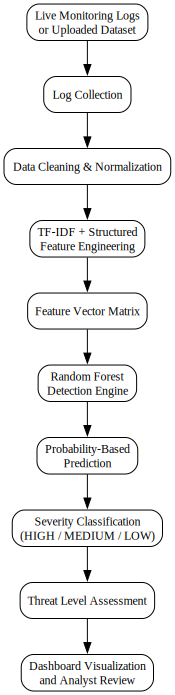

In [1]:
from graphviz import Digraph

dot = Digraph(
    comment='Adaptive ML-Based Log Anomaly Detection Pipeline',
    format='png'
)

dot.attr(rankdir='TB')
dot.attr('node',
         shape='box',
         style='rounded',
         fontsize='12')

dot.node('A', 'Live Monitoring Logs\nor Uploaded Dataset')
dot.node('B', 'Log Collection')
dot.node('C', 'Data Cleaning & Normalization')
dot.node('D', 'TF-IDF + Structured\nFeature Engineering')
dot.node('E', 'Feature Vector Matrix')
dot.node('F', 'Random Forest\nDetection Engine')
dot.node('G', 'Probability-Based\nPrediction')
dot.node('H', 'Severity Classification\n(HIGH / MEDIUM / LOW)')
dot.node('I', 'Threat Level Assessment')
dot.node('J', 'Dashboard Visualization\nand Analyst Review')

dot.edges([
    ('A','B'),
    ('B','C'),
    ('C','D'),
    ('D','E'),
    ('E','F'),
    ('F','G'),
    ('G','H'),
    ('H','I'),
    ('I','J')
])

dot.render('adaptive_ml_pipeline', view=True)

dot

In [1]:
import pandas as pd

dataset_summary = pd.DataFrame({
    "Dataset": ["HDFS", "BGL", "Combined"],
    "Total Records": [2000, 2000, 4000],
    "Normal Records": [1931, 143, 2074],
    "Anomalous Records": [69, 1857, 1926]
})

dataset_summary["Anomaly Rate (%)"] = (
    dataset_summary["Anomalous Records"]
    / dataset_summary["Total Records"]
    * 100
).round(2)

dataset_summary

,Dataset,Total Records,Normal Records,Anomalous Records,Anomaly Rate (%)
0,HDFS,2000,1931,69,3.45
1,BGL,2000,143,1857,92.85
2,Combined,4000,2074,1926,48.15


In [2]:
pip install dataframe-image

   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ------ --------------------------------- 1.0/6.7 MB 25.4 MB/s eta 0:00:01
   ------------ --------------------------- 2.1/6.7 MB 6.5 MB/s eta 0:00:01
   ------------------ --------------------- 3.1/6.7 MB 5.1 MB/s eta 0:00:01
   -------------------- ------------------- 3.4/6.7 MB 4.0 MB/s eta 0:00:01
   ------------------------- -------------- 4.2/6.7 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 6.7/6.7 MB 5.5 MB/s  0:00:01
   ---------------------------------------- 0.0/944.0 kB ? eta -:--:--
   ---------------------------------------- 944.0/944.0 kB 45.5 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 34.0 MB/s  0:00:00
   ---------------------------------------- 0.0/37.9 MB ? eta -:--:--
   -- ------------------------------------- 2.6/37.9 MB 13.7 MB/s eta 0:00:03
   ---- -----------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
dataset_summary.to_csv(
    r"E:\LogAnomalyDetector\reports\dataset_summary.csv",
    index=False
)

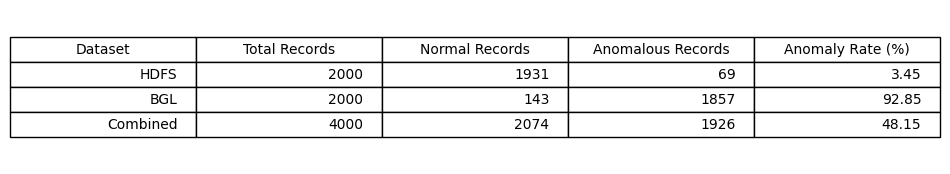

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2))

ax.axis('off')

tbl = ax.table(
    cellText=dataset_summary.values,
    colLabels=dataset_summary.columns,
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)

plt.savefig(
    r"E:\LogAnomalyDetector\reports\dataset_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()